# Modeling - With Business cost
Adding new features
`tilt_distance_ratio`
`neighbor_competition =avg_neighbor_advantage *overlap_ratio`
`overlap_sinr_penalty`

In [236]:
!pip install "numpy<2" --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] T

In [ ]:
#%restart

In [237]:
import numpy as np
import statsmodels.api as sm

print(np.__version__)
print(sm.__version__)

1.26.4
0.14.6


In [238]:
import json
import re
import math
import numpy as np
import pandas as pd
from io import StringIO

## Feature Engineering

In [239]:
def parse_tables(question):
    text = question.replace("\r\n", "\n").replace("\r", "\n")

    user_match = re.search(
        r"User plane drive test data as follows[：:]\s*\n+(.*?)(?:\n\s*\n\s*Engeneering parameters data as follows[：:]|\n\s*\n\s*Engineering parameters data as follows[：:])",
        text,
        flags=re.S
    )

    eng_match = re.search(
        r"(?:Engeneering|Engineering) parameters data as follows[：:]\s*\n+(.*)$",
        text,
        flags=re.S
    )

    if not user_match or not eng_match:
        raise ValueError("Could not find table blocks")

    def block_to_df(block):
        lines = []
        for line in block.splitlines():
            line = line.strip()
            if "|" in line:
                lines.append(line)

        # Repairs rare formatting issue like "g\nNodeB ID"
        if lines and lines[0].startswith("NodeB ID|"):
            lines[0] = "g" + lines[0]

        return pd.read_csv(StringIO("\n".join(lines)), sep="|")

    user_df = block_to_df(user_match.group(1))
    eng_df = block_to_df(eng_match.group(1))

    return user_df, eng_df


def beamwidth_from_scenario(s):
    if pd.isna(s):
        return np.nan

    s = str(s).upper()

    if "DEFAULT" in s:
        return 6

    match = re.search(r"SCENARIO_(\d+)", s)
    if match:
        n = int(match.group(1))
        if n <= 5:
            return 6
        elif n <= 11:
            return 12
        else:
            return 25

    return np.nan

# Calculate distance between vehicle GPS location and tower location
# C2: coverage distance exceeds 1 km -> To calculate distance
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0

    lon1, lat1, lon2, lat2 = map(
        np.radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

# longest consecutive streak of low throughput
def longest_streak_bool(values):
    max_streak = 0
    current = 0

    for value in values:
        if bool(value):
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak

def make_features(user_df, eng_df):
    # Taking care of missing data "-" as NaN
    user_df = user_df.copy().replace("-", np.nan)
    eng_df = eng_df.copy().replace("-", np.nan)

    # Define important column names
    tp_col = "5G KPI PCell Layer2 MAC DL Throughput [Mbps]"
    speed_col = "GPS Speed (km/h)"
    # "What cell is the UE connected to?"
    pci_col = "5G KPI PCell RF Serving PCI"
    # "How strong is the signal?"
    rsrp_col = "5G KPI PCell RF Serving SS-RSRP [dBm]"
    # "How clean is the signal?"
    sinr_col = "5G KPI PCell RF Serving SS-SINR [dB]"
    # "How many RBs are being used?"
    rb_col = "5G KPI PCell Layer1 DL RB Num (Including 0)"

    neighbor_pci_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} PCI"
        for i in range(1, 6)
    ]

    neighbor_brsrp_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} Filtered Tx BRSRP [dBm]"
        for i in range(1, 6)
    ]

    numeric_user_cols = [
        "Longitude", "Latitude",
        tp_col, speed_col, pci_col, rsrp_col, sinr_col, rb_col
    ] + neighbor_pci_cols + neighbor_brsrp_cols

    # Convert text numbers into numeric values
    for col in numeric_user_cols:
        if col in user_df.columns:
            user_df[col] = pd.to_numeric(user_df[col], errors="coerce")

    numeric_eng_cols = [
        "Longitude", "Latitude", "Mechanical Downtilt",
        "Digital Tilt", "Height", "PCI"
    ]

    for col in numeric_eng_cols:
        eng_df[col] = pd.to_numeric(eng_df[col], errors="coerce")

    # Engineering transformations
    # we replace 255 with 6.
    eng_df["digital_tilt_clean"] = eng_df["Digital Tilt"].replace(255, 6)
    # effective_tilt = mechanical downtilt + digital tilt -> Can be useful for C1: downtilt too large
    eng_df["effective_tilt"] = (
        eng_df["Mechanical Downtilt"] + eng_df["digital_tilt_clean"]
    )
    eng_df["beamwidth"] = eng_df["Beam Scenario"].apply(beamwidth_from_scenario)

    #print("Engineering data after transformations:")
    #print(eng_df)

    eng_by_pci = (
        eng_df
        .dropna(subset=["PCI"])
        .drop_duplicates("PCI")
        .set_index("PCI")
    )

    features = {}

    tp = user_df[tp_col]
    low_mask = tp < 600
    low_df = user_df[low_mask]

    # -----------------------------
    # Throughput features
    # -----------------------------
    features["avg_throughput"] = tp.mean()
    features["min_throughput"] = tp.min()
    features["std_throughput"] = tp.std()
    features["low_tp_count"] = int(low_mask.sum())
    features["low_tp_ratio"] = low_mask.mean()
    features["avg_throughput_low_tp"] = low_df[tp_col].mean()
    features["consecutive_low_tp_max"] = longest_streak_bool(low_mask.tolist())

    # -----------------------------
    # Speed features
    # -----------------------------
    speed = user_df[speed_col]

    features["max_speed"] = speed.max()
    features["pct_speed_above_40"] = (speed > 40).mean()
    features["avg_speed_low_tp"] = low_df[speed_col].mean()
    features["max_speed_low_tp"] = low_df[speed_col].max()

    # -----------------------------
    # Handover features
    # -----------------------------
    serving_pci = user_df[pci_col]

    features["num_unique_serving_pci"] = serving_pci.nunique()

    switches = (
        (serving_pci != serving_pci.shift())
        & serving_pci.notna()
        & serving_pci.shift().notna()
    )

    features["handover_count"] = int(switches.sum())
    features["handover_rate"] = features["handover_count"] / max(len(user_df) - 1, 1)

    if len(low_df) > 1:
        low_pci = low_df[pci_col]
        low_switches = (
            (low_pci != low_pci.shift())
            & low_pci.notna()
            & low_pci.shift().notna()
        )
        features["handover_count_low_tp"] = int(low_switches.sum())
    else:
        features["handover_count_low_tp"] = 0

    # -----------------------------
    # Signal quality features
    # -----------------------------
    features["avg_rsrp"] = user_df[rsrp_col].mean()
    features["min_rsrp"] = user_df[rsrp_col].min()
    features["avg_rsrp_low_tp"] = low_df[rsrp_col].mean()

    features["avg_sinr"] = user_df[sinr_col].mean()
    features["min_sinr"] = user_df[sinr_col].min()
    features["avg_sinr_low_tp"] = low_df[sinr_col].mean()


    # NEW SINR FEATURES
    features["std_sinr"] = user_df[sinr_col].std()

    SINR_THRESHOLD = 5
    features["pct_sinr_below_5"] = (user_df[sinr_col] < SINR_THRESHOLD).mean()

    features["min_sinr_low_tp"] = low_df[sinr_col].min()

    # -----------------------------
    # RB features
    # -----------------------------
    rb = user_df[rb_col]

    features["avg_rb"] = rb.mean()
    features["min_rb"] = rb.min()
    features["avg_rb_low_tp"] = low_df[rb_col].mean()
    features["min_rb_low_tp"] = low_df[rb_col].min()
    features["pct_rb_below_160"] = (rb < 160).mean()
    

    # -----------------------------
    # Neighbor + PCI mod 30 features
    # -----------------------------
    neighbor_advantages = []
    neighbor_stronger_flags = []
    close_neighbor_counts = []
    same_mod30_flags = []
    same_mod30_counts = []

    for _, row in user_df.iterrows():
        serving_rsrp = row[rsrp_col]
        serving_pci_value = row[pci_col]

        neighbor_brsrps = [
            row[col] for col in neighbor_brsrp_cols
            if col in user_df.columns and pd.notna(row[col])
        ]

        neighbor_pcis = [
            row[col] for col in neighbor_pci_cols
            if col in user_df.columns
        ]

        # Neighbor strength
        if neighbor_brsrps and pd.notna(serving_rsrp):
            strongest_neighbor = max(neighbor_brsrps)
            advantage = strongest_neighbor - serving_rsrp

            neighbor_advantages.append(advantage)
            neighbor_stronger_flags.append(strongest_neighbor > serving_rsrp)

            close_count = sum(
                abs(x - serving_rsrp) <= 3
                for x in neighbor_brsrps
            )
            close_neighbor_counts.append(close_count)

        # PCI mod 30 conflict
        mod30_count = 0

        if pd.notna(serving_pci_value):
            for neighbor_pci in neighbor_pcis:
                if pd.notna(neighbor_pci):
                    if int(neighbor_pci) % 30 == int(serving_pci_value) % 30:
                        mod30_count += 1

        same_mod30_counts.append(mod30_count)
        same_mod30_flags.append(mod30_count > 0)

    features["avg_neighbor_advantage"] = (
        np.nanmean(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["max_neighbor_advantage"] = (
        np.nanmax(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["neighbor_stronger_ratio"] = (
        np.mean(neighbor_stronger_flags) if neighbor_stronger_flags else np.nan
    )
    features["avg_close_neighbor_count"] = (
        np.nanmean(close_neighbor_counts) if close_neighbor_counts else np.nan
    )
    features["overlap_ratio"] = (
        np.mean([x > 0 for x in close_neighbor_counts])
        if close_neighbor_counts else np.nan
    )

    features["same_mod30_exists"] = int(any(same_mod30_flags))
    features["same_mod30_count"] = np.sum(same_mod30_counts)
    features["same_mod30_ratio"] = np.mean(same_mod30_flags)

    # ----------------------------------------
    # neighbor_competition = avg_neighbor_advantage * overlap_ratio
    # ----------------------------------------
    neighbor_adv = features.get(
    "avg_neighbor_advantage",
        np.nan
    )

    overlap = features.get(
        "overlap_ratio",
        np.nan
    )

    features["neighbor_competition"] = (
        neighbor_adv * overlap
        if pd.notna(neighbor_adv)
        and pd.notna(overlap)
        else np.nan
    )

    # ----------------------------------------
    # TxRx Mode (categorical)
    # ----------------------------------------

    txrx_vals = eng_df["TxRx Mode"].dropna()

    features["txrx_mode"] = (
        txrx_vals.mode().iloc[0]
        if len(txrx_vals) > 0
        else "Unknown"
    )

    # ----------------------------------------
    # Antenna Model (categorical)
    # ----------------------------------------

    antenna_vals = eng_df["Antenna Model"].dropna()

    features["antenna_model"] = (
        antenna_vals.mode().iloc[0]
        if len(antenna_vals) > 0
        else "Unknown"
    )

    # -----------------------------
    # Engineering + distance features
    # -----------------------------
    serving_tilts = []
    serving_beamwidths = []
    serving_heights = []
    serving_distances = []
    serving_distances_low_tp = []

    for idx, row in user_df.iterrows():
        serving_pci_value = row[pci_col]

        if pd.notna(serving_pci_value) and serving_pci_value in eng_by_pci.index:
            eng_row = eng_by_pci.loc[serving_pci_value]

            serving_tilts.append(eng_row["effective_tilt"])
            serving_beamwidths.append(eng_row["beamwidth"])
            serving_heights.append(eng_row["Height"])

            dist = haversine(
                row["Longitude"],
                row["Latitude"],
                eng_row["Longitude"],
                eng_row["Latitude"]
            )

            serving_distances.append(dist)

            if low_mask.iloc[idx]:
                serving_distances_low_tp.append(dist)

    features["avg_serving_tilt"] = (
        np.nanmean(serving_tilts) if serving_tilts else np.nan
    )
    features["max_serving_tilt"] = (
        np.nanmax(serving_tilts) if serving_tilts else np.nan
    )
    features["avg_serving_beamwidth"] = (
        np.nanmean(serving_beamwidths) if serving_beamwidths else np.nan
    )
    features["avg_serving_height"] = (
        np.nanmean(serving_heights) if serving_heights else np.nan
    )

    features["avg_serving_distance_km"] = (
        np.nanmean(serving_distances) if serving_distances else np.nan
    )
    features["max_serving_distance_km"] = (
        np.nanmax(serving_distances) if serving_distances else np.nan
    )
    features["pct_distance_gt_1km"] = (
        np.mean([d > 1 for d in serving_distances])
        if serving_distances else np.nan
    )
    features["avg_distance_low_tp"] = (
        np.nanmean(serving_distances_low_tp)
        if serving_distances_low_tp else np.nan
    )

    # C1 feature:
    # excessive tilt + weak signal

    features["tilt_rsrp_interaction"] = (
        features["avg_serving_tilt"]
        *
        abs(features["min_rsrp"])
    )


    return features


In [240]:
with open("../data/train.json", "r") as f:
    train = json.load(f)

rows = []

for item in train:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    rows.append(features)

ml_df = pd.DataFrame(rows)

print(ml_df.shape)
print(ml_df.head())
print(ml_df["answer"].value_counts())

# Optional: save engineered dataset
ml_df.to_csv("telelogs_engineered_features.csv", index=False)

(2400, 50)
   avg_throughput  min_throughput  std_throughput  low_tp_count  low_tp_ratio  \
0         847.792          334.00      407.163069             4           0.4   
1         850.051          388.58      345.211857             4           0.4   
2         671.739          258.08      295.071300             4           0.4   
3         921.430          407.35      399.562308             4           0.4   
4         789.406          319.87      366.988478             4           0.4   

   avg_throughput_low_tp  consecutive_low_tp_max  max_speed  \
0               424.7125                       4         33   
1               470.3825                       4         33   
2               338.5225                       4         36   
3               459.8275                       4         32   
4               404.2275                       4         32   

   pct_speed_above_40  avg_speed_low_tp  ...  avg_serving_tilt  \
0                 0.0             12.75  ...             

## C1 vs C3 EDA

In [241]:
ml_df["tilt_rsrp_interaction"] = (
        ml_df["avg_serving_tilt"]
        *
        abs(ml_df["min_rsrp"])
    )

In [242]:
ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )


0       True
1       True
2       True
3       True
4       True
        ... 
2395    True
2396    True
2397    True
2398    True
2399    True
Name: answer, Length: 2400, dtype: bool

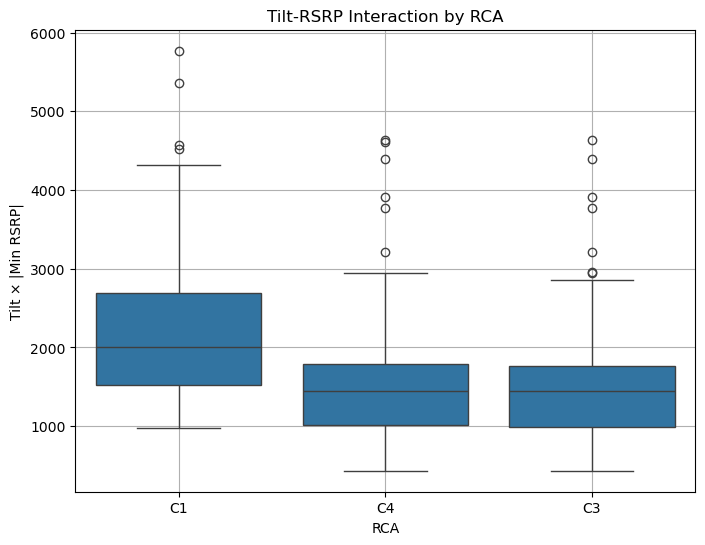

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns

subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C3", "C4"]
    )
]

plt.figure(figsize=(8,6))


sns.boxplot(
    data=subset,
    x="answer",
    y="tilt_rsrp_interaction",
)

plt.title(
    "Tilt-RSRP Interaction by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Tilt × |Min RSRP|"
)

plt.grid(True)
plt.show()

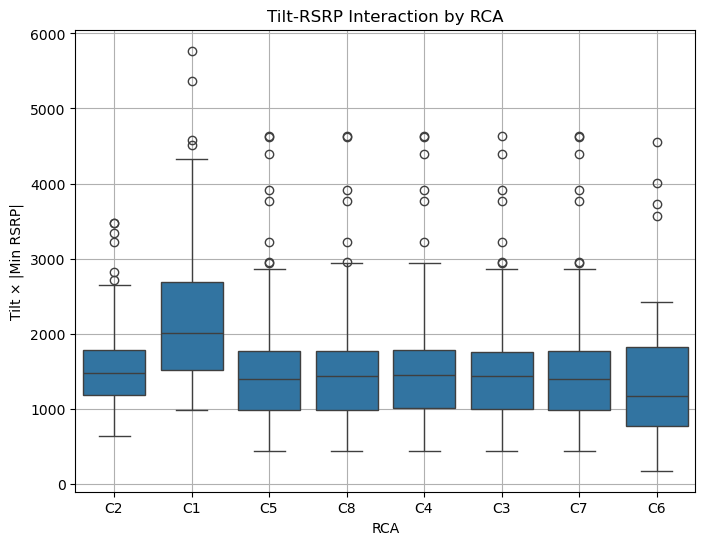

In [244]:
subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )
]

plt.figure(figsize=(8,6))


sns.boxplot(
    data=subset,
    x="answer",
    y="tilt_rsrp_interaction",
)

plt.title(
    "Tilt-RSRP Interaction by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Tilt × |Min RSRP|"
)

plt.grid(True)
plt.show()

In [245]:
print(
    ml_df["min_rsrp"].describe()
)

count    2400.000000
mean      -88.591342
std         1.597387
min       -94.720000
25%       -89.350000
50%       -88.630000
75%       -87.610000
max       -85.000000
Name: min_rsrp, dtype: float64


C1 showed noticeably higher tilt-RSRP interaction values
Better separation was observed between C1 and neighboring-cell related issues (C3/C4)
Min rsrp are negative values. The higher absolute of min_rsrp value the it means it actually had the lowest rsrp which means the lowest signal.


## C3 vs C4

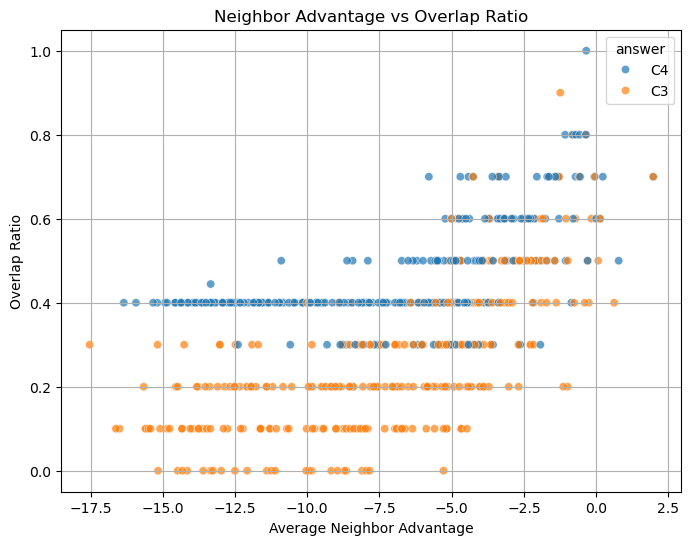

In [246]:
subset = ml_df[
    ml_df["answer"].isin(
        ["C3", "C4"]
    )
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=subset,
    x="avg_neighbor_advantage",
    y="overlap_ratio",
    hue="answer",
    alpha=0.7
)

plt.title(
    "Neighbor Advantage vs Overlap Ratio"
)
plt.xlabel(
    "Average Neighbor Advantage"
)
plt.ylabel(
    "Overlap Ratio"
)

plt.grid(True)
plt.show()

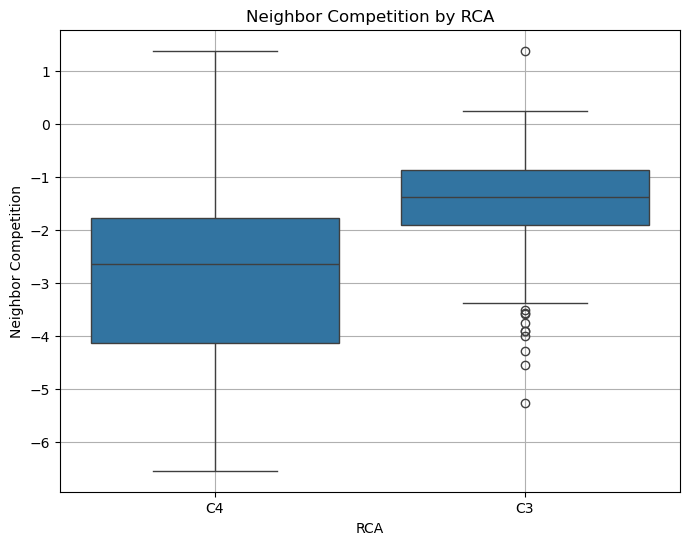

In [247]:
ml_df["neighbor_competition"] = (
    ml_df["avg_neighbor_advantage"]
    *
    ml_df["overlap_ratio"]
)

subset = ml_df[
    ml_df["answer"].isin(
        ["C3", "C4"]
    )
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=subset,
    x="answer",
    y="neighbor_competition"
)

plt.title(
    "Neighbor Competition by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Neighbor Competition"
)

plt.grid(True)
plt.show()

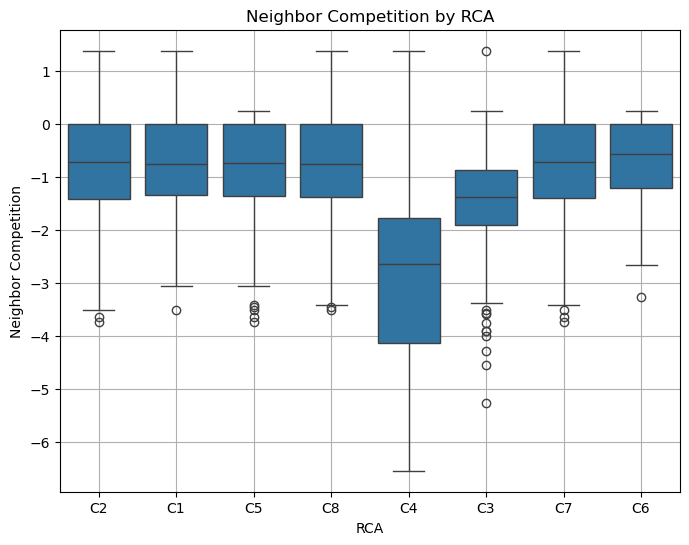

In [248]:
ml_df["neighbor_competition"] = (
    ml_df["avg_neighbor_advantage"]
    *
    ml_df["overlap_ratio"]
)

subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=subset,
    x="answer",
    y="neighbor_competition"
)

plt.title(
    "Neighbor Competition by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Neighbor Competition"
)

plt.grid(True)
plt.show()

C4: was overlapping from neiboring cells
much lower (more negative)
neighbor competition


* C4 demonstrated the strongest overlap-driven neighbor interaction, supporting its interpretation as a severe co-frequency overlap issue.
* C3 exhibited moderate neighbor competition, aligning with a stronger neighboring-cell scenario rather than widespread interference.
* Neighbor competition showed improved class-specific separation for C3/C4 compared with other RCA classes, suggesting potential value for reducing model confusion between neighboring-cell-related failures.

## 1. Logistic Regression

### Seperate Explanatory variables and a Target Variable

In [249]:
X = ml_df.drop("answer", axis=1)
y = ml_df["answer"]

In [250]:
from sklearn.impute import SimpleImputer
import pandas as pd

# -----------------------------
# Numeric & categorical split
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(exclude=["number"]).columns

# Numeric
num_imputer = SimpleImputer(strategy="median")

X_numeric = pd.DataFrame(
    num_imputer.fit_transform(X[numeric_cols]),
    columns=numeric_cols,
    index=X.index
)

# Categorical
cat_imputer = SimpleImputer(strategy="most_frequent")

X_categorical = pd.DataFrame(
    cat_imputer.fit_transform(X[categorical_cols]),
    columns=categorical_cols,
    index=X.index
)

# Combine
X_imputed = pd.concat(
    [X_numeric, X_categorical],
    axis=1
)

X_imputed

,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,tilt_rsrp_interaction,txrx_mode,antenna_model
0,847.792,334.00,407.163069,4.0,0.4,424.7125,4.0,33.0,0.0,12.75,...,14.0,6.0,14.88,1.122599,2.774421,0.4,2.771672,1164.372,64T64R,NR AAU 2
1,850.051,388.58,345.211857,4.0,0.4,470.3825,4.0,33.0,0.0,12.75,...,53.0,6.0,27.84,0.047804,0.068577,0.0,0.044401,2445.844,64T64R,NR AAU 2
2,671.739,258.08,295.071300,4.0,0.4,338.5225,4.0,36.0,0.0,16.00,...,27.0,8.4,32.40,0.769140,1.698408,0.4,1.698408,1671.780,32T32R,NR AAU 3
3,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,25.54,1.295369,2.976701,0.4,2.957331,1090.680,64T64R,NR AAU 2
4,789.406,319.87,366.988478,4.0,0.4,404.2275,4.0,32.0,0.0,22.75,...,26.0,15.5,11.75,0.192364,0.263115,0.0,0.183851,1196.300,64T64R,NR AAU 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,698.910,290.00,293.175211,4.0,0.4,386.1975,4.0,31.0,0.0,15.00,...,22.0,10.2,23.37,0.115415,0.141225,0.0,0.126174,1329.750,64T64R,NR AAU 2
2396,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,34.36,0.188000,0.314276,0.0,0.207184,1448.280,64T64R,NR AAU 2
2397,644.153,325.71,265.283421,4.0,0.4,340.1050,4.0,36.0,0.0,20.25,...,27.0,6.0,52.36,0.126494,0.207267,0.0,0.149572,2045.967,32T32R,NR AAU 3
2398,728.994,117.97,395.994842,4.0,0.4,312.5125,4.0,38.0,0.0,7.00,...,27.0,12.0,48.50,0.192103,0.240620,0.0,0.211130,2391.402,64T64R,NR AAU 2


### One Hot Encoding for Categorical Variables

In [251]:
X_encoded = pd.get_dummies(
    X_imputed,
    drop_first=True
)

print(X_encoded.shape)

(2400, 50)


### Test/Train split

In [252]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Normalization/ Standard scaling for Logistic Regression

In [253]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Fitting the Logistic Regression model

In [254]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class="multinomial",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=5000,
                   multi_class='multinomial', random_state=42)

In [255]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [256]:
coef_df = pd.DataFrame(
    log_model.coef_.T,
    index=X_encoded.columns,
    columns=log_model.classes_
)

coef_long = (
    coef_df
    .reset_index()
    .melt(
        id_vars="index",
        var_name="RCA",
        value_name="Coefficient"
    )
    .rename(columns={
        "index": "Feature"
    })
)

coef_long["Abs_Coefficient"] = (
    coef_long["Coefficient"]
    .abs()
)

coef_long = coef_long.sort_values(
    ["RCA", "Abs_Coefficient"],
    ascending=[True, False]
)

display(
    coef_long.round(4)
)

,Feature,RCA,Coefficient,Abs_Coefficient
29,avg_neighbor_advantage,C1,-1.5588,1.5588
16,min_rsrp,C1,-1.1104,1.1104
15,avg_rsrp,C1,-0.9482,0.9482
1,min_throughput,C1,0.9093,0.9093
41,avg_serving_height,C1,-0.9005,0.9005
...,...,...,...,...
356,consecutive_low_tp_max,C8,0.0015,0.0015
395,avg_distance_low_tp,C8,0.0008,0.0008
392,avg_serving_distance_km,C8,-0.0003,0.0003
361,num_unique_serving_pci,C8,0.0003,0.0003


### Prediction

In [257]:
preds = log_model.predict(X_test_scaled)

probs = log_model.predict_proba(
    X_test_scaled
)

### Evaluation Metrics

In [258]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, preds))

print("Precision:",
      precision_score(
          y_test,
          preds,
          average="macro"
      ))

print("Recall:",
      recall_score(
          y_test,
          preds,
          average="macro"
      ))

print("F1:",
      f1_score(
          y_test,
          preds,
          average="macro"
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          probs,
          multi_class="ovr",
          average="macro"
      ))

Accuracy: 0.9541666666666667
Precision: 0.9547210953346856
Recall: 0.9531536818031356
F1: 0.9538083642572279
ROC-AUC: 0.9968951503129381


#### LR - ROC-AUC Plot

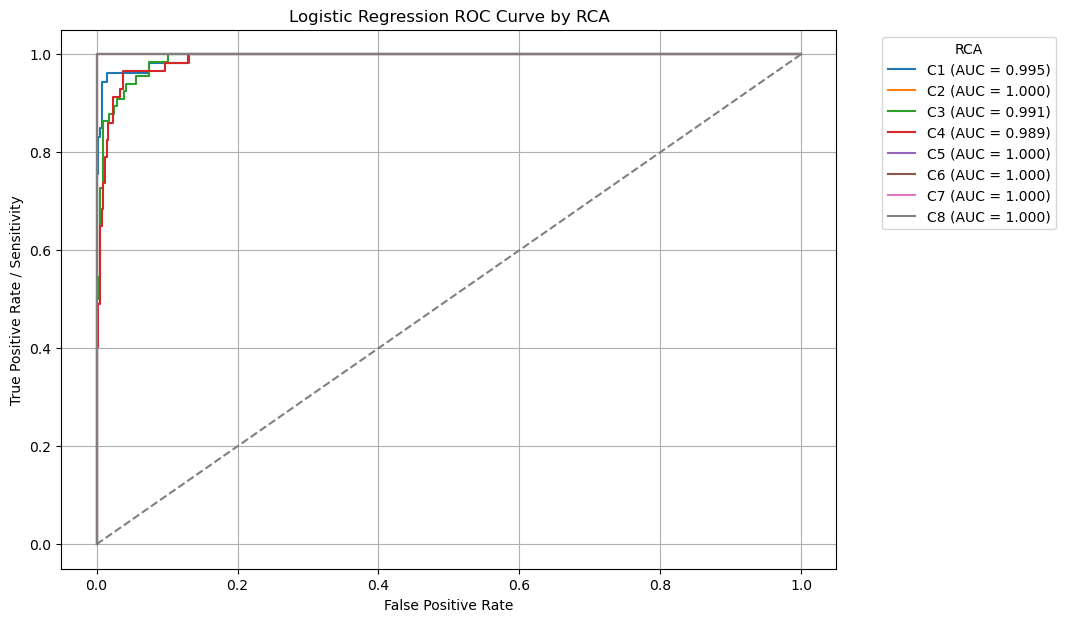

In [259]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Class labels
classes = log_model.classes_

# Binarize y_test for One-vs-Rest ROC
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
y_score = probs

plt.figure(figsize=(10, 7))

roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)
    roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("Logistic Regression ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

AUC ≈ 0.99–1.00 for almost every class with baseline Logistic Regression. Which is suspiciously high. There might be data leakage here.


#### LR - Precision-recall curve plot

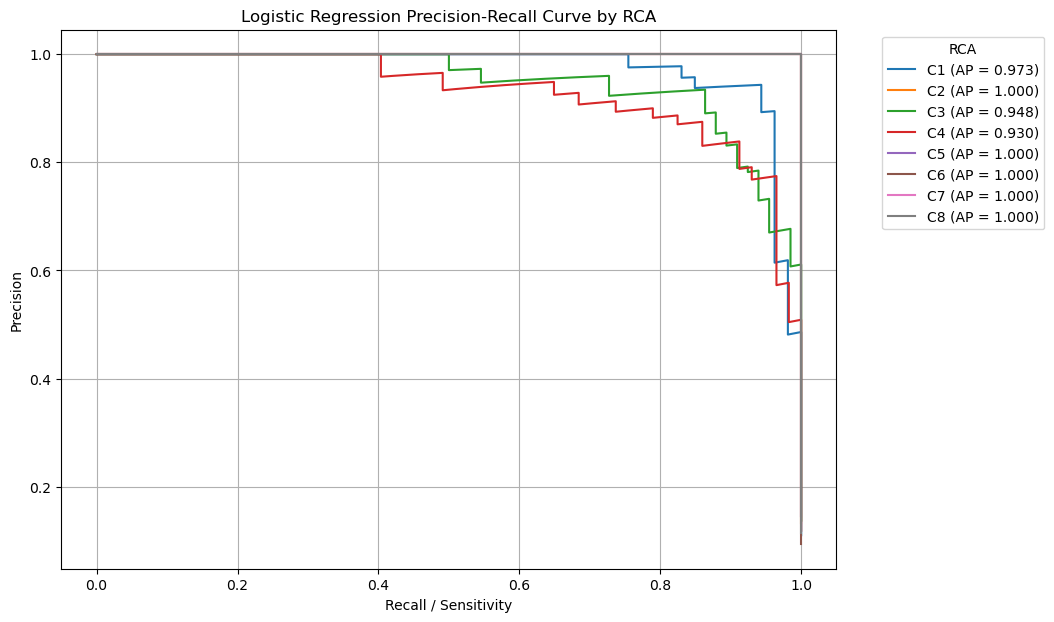

In [260]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

    pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("Logistic Regression Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

#### Youden's J

In [261]:
from sklearn.metrics import confusion_matrix
import pandas as pd

youden_results = []

for cls in classes:
    # One-vs-rest conversion
    y_true_binary = (y_test == cls).astype(int)
    y_pred_binary = (preds == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

youden_df = pd.DataFrame(youden_results)

display(
    youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
0,C1,0.887,0.993,0.880
2,C3,0.879,0.976,0.855
3,C4,0.860,0.979,0.838


### LR - Confusion Matrix

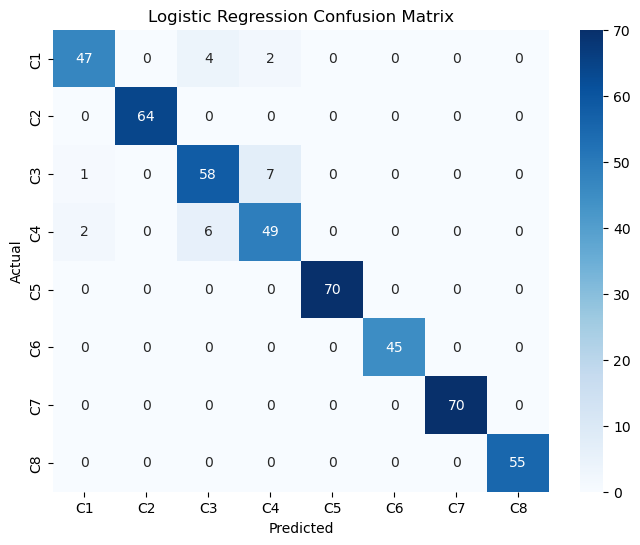

In [262]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix Observations – Logistic Regression

* **Overall classification performance was strong**, achieving approximately **94.5% accuracy and macro F1**, suggesting that engineered telecom KPIs effectively distinguish RCA categories.

* **C2 (Coverage Overshooting) was perfectly classified** with **100% precision and recall**, indicating that overshooting scenarios exhibit a highly distinctive KPI signature, particularly through serving distance features.

* **C5 and C7 also achieved near-perfect classification**, suggesting that mobility and handover-related degradation mechanisms are highly separable from other RCA categories.

* **C6 (PCI Conflict) demonstrated excellent performance** (**Precision = 0.98, Recall = 1.00**), supporting the effectiveness of modulo-30 PCI conflict features (`same_mod30_ratio`, `same_mod30_count`) for identifying interference-related RCA.

* **C8 (Resource Insufficiency) was perfectly identified**, reinforcing EDA findings that RB-related features create a distinct degradation pattern.

* **The model struggled most with C1, C3, and C4**, where moderate confusion was observed between categories.

* **C3 and C4 showed the highest overlap**, indicating that neighboring-cell throughput issues and overlapping coverage may exhibit similar telecom KPI behavior, making separation more challenging for a linear model.

* **C1 occasionally overlapped with C3/C4**, suggesting that some tilt-related scenarios may share characteristics with neighboring-cell or overlap-driven degradation.

* Despite a very high **ROC-AUC (~0.996)**, the confusion matrix suggests that some RCA mechanisms remain operationally similar, highlighting opportunities for **nonlinear models (e.g., XGBoost, LightGBM)** to further improve separation among overlapping classes.


### LR - Classification Report

In [263]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

          C1       0.94      0.89      0.91        53
          C2       1.00      1.00      1.00        64
          C3       0.85      0.88      0.87        66
          C4       0.84      0.86      0.85        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.95       480
   macro avg       0.95      0.95      0.95       480
weighted avg       0.95      0.95      0.95       480



### Checking for any data leakage as we are seeing high accuaracy and high RPC and precisions for each classes. 

In [264]:
coef_df = pd.DataFrame(
    log_model.coef_.T,
    index=X_encoded.columns,
    columns=log_model.classes_
)

coef_df.abs().max(axis=1)\
    .sort_values(ascending=False)\
    .head(20)

same_mod30_ratio          1.896729
neighbor_competition      1.847955
min_throughput            1.835494
avg_throughput_low_tp     1.828655
same_mod30_count          1.760259
avg_neighbor_advantage    1.558806
handover_count            1.427563
handover_rate             1.427563
pct_speed_above_40        1.397057
min_rsrp                  1.110400
std_throughput            1.038213
handover_count_low_tp     1.017273
avg_speed_low_tp          1.003649
max_speed                 0.977412
pct_rb_below_160          0.958386
avg_rsrp                  0.948177
avg_serving_height        0.900495
max_speed_low_tp          0.887403
avg_rb_low_tp             0.848586
max_serving_tilt          0.796980
dtype: float64

Although the Logistic Regression model achieved near-perfect performance, this appears to be a case of **domain-rule leakage rather than traditional data leakage**. Traditional data leakage occurs when information from the target variable or test set is unintentionally exposed to the model during training. In contrast, our engineered features were intentionally derived from domain knowledge and closely reflect the RCA definitions provided in the TeleLogs framework. For example, features such as `same_mod30_ratio`, `overlap_ratio`, `handover_count`, and `pct_rb_below_160` directly correspond to predefined RCA mechanisms such as PCI mod 30 conflict, overlapping coverage, frequent handovers, and insufficient RB allocation. As a result, the model is not memorizing hidden labels or test information, but rather learning structured telecom troubleshooting rules embedded in the feature space. This explains the unusually strong baseline performance and suggests that the model is effectively leveraging engineered telecom expertise to infer root causes.


### LR - Internal CV

Macro-averaged evaluation metrics were used to ensure that all RCA categories contributed equally to model performance, regardless of class frequency. Since the objective of RCA classification is to reliably identify all failure mechanisms rather than favor majority classes, macro averaging provides a more balanced assessment of predictive performance across root causes.

In [265]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# -----------------------------
# X and y
# -----------------------------

X = ml_df.drop("answer", axis=1).copy()

# Force categorical columns to plain Python strings
for col in ["txrx_mode", "antenna_model"]:
    if col in X.columns:
        X[col] = X[col].astype("object").fillna("Missing").astype(str)

# Force numeric columns to numeric
for col in X.columns:
    if col not in ["txrx_mode", "antenna_model"]:
        X[col] = pd.to_numeric(X[col], errors="coerce")

y = ml_df["answer"].astype(str)

# -----------------------------
# Columns
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = ["txrx_mode", "antenna_model"]

print(X.dtypes.value_counts())
print("Numeric:", len(numeric_cols))
print("Categorical:", categorical_cols)

# -----------------------------
# Preprocessing
# -----------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# -----------------------------
# Model
# -----------------------------

log_model_cv = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
    solver="lbfgs"
)

log_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", log_model_cv)
    ]
)

# -----------------------------
# CV
# -----------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

cv_results = cross_validate(
    log_pipeline,
    X,
    y,
    scoring=scoring,
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    error_score="raise"
)

# -----------------------------
# Results
# -----------------------------

for metric in scoring.keys():
    train_scores = cv_results[f"train_{metric}"]
    test_scores = cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {np.mean(train_scores):.3f} ({np.std(train_scores):.3f})")
    print(f"  Test : {np.mean(test_scores):.3f} ({np.std(test_scores):.3f})")
    print("-" * 40)

float64    38
int64       9
str         2
Name: count, dtype: int64
Numeric: 47
Categorical: ['txrx_mode', 'antenna_model']
accuracy
  Train: 0.964 (0.002)
  Test : 0.949 (0.008)
----------------------------------------
precision_macro
  Train: 0.963 (0.002)
  Test : 0.948 (0.009)
----------------------------------------
recall_macro
  Train: 0.964 (0.002)
  Test : 0.948 (0.008)
----------------------------------------
f1_macro
  Train: 0.963 (0.002)
  Test : 0.948 (0.009)
----------------------------------------
roc_auc_ovr
  Train: 0.998 (0.000)
  Test : 0.996 (0.000)
----------------------------------------


**Logistic Regression Baseline**

Even a simple interpretable model achieved:

94.5% F1
99.6% ROC-AUC

suggesting:

**telecom RCA mechanisms are strongly explainable through engineered KPIs.**

However:

C3/C4/C1

showed higher confusion due to overlapping telecom behavior.

While:

C2/C5/C6/C7/C8

were highly distinguishable.

#### Assumption check
##### 1. Multicolinearity

In [266]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# numeric only
X_num = X_encoded.select_dtypes(include=np.number)

vif_df = pd.DataFrame()
vif_df["Feature"] = X_num.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_num.values, i
    )
    for i in range(X_num.shape[1])
]

vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

vif_df.head(50)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
3,low_tp_count,inf
4,low_tp_ratio,inf
12,handover_count,inf
13,handover_rate,inf
11,num_unique_serving_pci,2.721544e+04
46,tilt_rsrp_interaction,2.142030e+03
38,avg_serving_tilt,2.086583e+03
44,pct_distance_gt_1km,8.415125e+02
43,max_serving_distance_km,6.498896e+02
45,avg_distance_low_tp,5.044539e+02


Variance Inflation Factor (VIF) analysis revealed substantial multicollinearity among engineered telecom features, particularly within groups describing similar network behaviors (e.g., handover activity, SINR quality, serving distance, RB allocation, and low-throughput periods). Several variables exhibited extremely high or infinite VIF values due to mathematical dependence or strong conceptual overlap (e.g., `handover_count` and `handover_rate`, `low_tp_count` and `low_tp_ratio`). While multicollinearity may reduce coefficient interpretability in Logistic Regression, it is less problematic for predictive performance, as reflected by stable internal cross-validation results. Since the primary objective of this study is RCA prediction rather than coefficient inference, correlated telecom KPIs were retained to preserve domain-relevant signal for downstream machine learning models.


#### 2. Linear relationship with log-odds

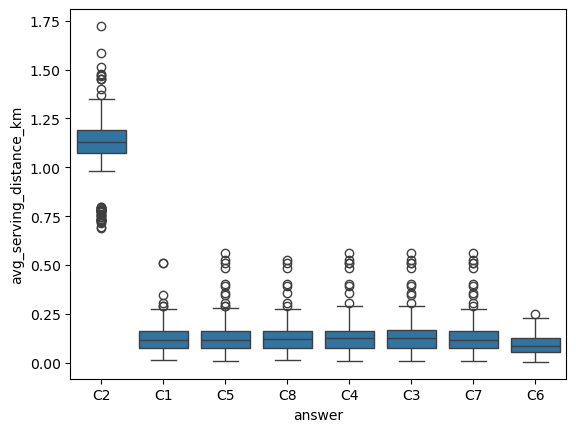

In [267]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=ml_df,
    x="answer",
    y="avg_serving_distance_km"
)

plt.show()

#### 3. No extreme class imbalance

#### 4. Independence of observations ⚠️
We will assume that each observation is independent to each other.

In [268]:
X_encoded.describe().T[
    ["min","25%","50%","75%","max"]
]

,min,25%,50%,75%,max
avg_throughput,504.807000,640.596000,711.197000,819.266000,1197.858000
min_throughput,0.000000,190.530000,273.540000,374.910000,665.300000
std_throughput,180.387110,302.501276,355.970841,409.940624,607.363614
low_tp_count,0.000000,4.000000,4.000000,4.000000,4.000000
low_tp_ratio,0.000000,0.400000,0.400000,0.400000,0.400000
avg_throughput_low_tp,45.830000,263.658125,340.105000,431.155000,593.750000
consecutive_low_tp_max,0.000000,4.000000,4.000000,4.000000,4.000000
max_speed,22.000000,35.000000,37.000000,39.000000,79.000000
pct_speed_above_40,0.000000,0.000000,0.000000,0.000000,0.400000
avg_speed_low_tp,2.000000,16.000000,20.750000,26.500000,77.250000


Descriptive statistics did not indicate substantial extreme outliers that would likely distort Logistic Regression performance. Although some variables exhibited wider ranges (e.g., serving distance and PCI-related features), these observations reflect meaningful telecom behaviors associated with RCA mechanisms (e.g., coverage overshooting or PCI conflict) rather than data quality issues. Therefore, potentially extreme values were retained to preserve operational signal relevant for root cause classification.


### VIF

In [269]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np

# ============================================================
# Use FULL one-hot encoded train dataset
# ============================================================

X_vif = X_encoded.copy()

# Make everything numeric
X_vif = X_vif.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace inf values
X_vif = X_vif.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values
X_vif = X_vif.fillna(
    X_vif.median()
)

# Convert all to float
X_vif = X_vif.astype(float)

# ============================================================
# Add intercept / constant
# ============================================================

X_vif_const = sm.add_constant(
    X_vif,
    has_constant="add"
)

# ============================================================
# Calculate VIF
# ============================================================

vif_df = pd.DataFrame()

vif_df["Feature"] = X_vif_const.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif_const.values.astype(float),
        i
    )
    for i in range(
        X_vif_const.shape[1]
    )
]

# Sort high → low
vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

# Display
display(
    vif_df.round(3)
)

# Optional: only high VIF variables
high_vif = vif_df[
    vif_df["VIF"] > 10
]

print("\nHigh VIF Variables (>10):")
display(
    high_vif.round(3)
)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
45,pct_distance_gt_1km,inf
4,low_tp_count,inf
5,low_tp_ratio,inf
12,num_unique_serving_pci,inf
13,handover_count,inf
14,handover_rate,inf
47,tilt_rsrp_interaction,2169.790
39,avg_serving_tilt,2111.598
44,max_serving_distance_km,665.628
46,avg_distance_low_tp,517.911



High VIF Variables (>10):


,Feature,VIF
45,pct_distance_gt_1km,inf
4,low_tp_count,inf
5,low_tp_ratio,inf
12,num_unique_serving_pci,inf
13,handover_count,inf
14,handover_rate,inf
47,tilt_rsrp_interaction,2169.790
39,avg_serving_tilt,2111.598
44,max_serving_distance_km,665.628
46,avg_distance_low_tp,517.911


In [270]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np

# -----------------------------
# Columns to drop due to redundancy / high VIF
# -----------------------------

drop_vif_cols = [
    "low_tp_count",
    "low_tp_ratio",
    "consecutive_low_tp_max",
    "handover_count",
    "max_serving_distance_km",
    "avg_distance_low_tp",
    "avg_sinr_low_tp",
    "min_sinr",
    "avg_rb_low_tp",
    "min_rb_low_tp",
    "avg_serving_tilt",
    "min_sinr_low_tp",
    "std_throughput",
    "pct_distance_gt_1km"
    

]

# -----------------------------
# Create reduced encoded dataset
# -----------------------------

X_vif_reduced = X_encoded.copy()

X_vif_reduced = X_vif_reduced.drop(
    columns=[
        col for col in drop_vif_cols
        if col in X_vif_reduced.columns
    ]
)

# Make sure everything is numeric
X_vif_reduced = X_vif_reduced.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace inf values
X_vif_reduced = X_vif_reduced.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values
X_vif_reduced = X_vif_reduced.fillna(
    X_vif_reduced.median()
)

# Force float
X_vif_reduced = X_vif_reduced.astype(float)

# -----------------------------
# Add constant
# -----------------------------

X_vif_reduced_const = sm.add_constant(
    X_vif_reduced,
    has_constant="add"
)

# -----------------------------
# Recalculate VIF
# -----------------------------

vif_reduced_df = pd.DataFrame({
    "Feature": X_vif_reduced_const.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_reduced_const.values.astype(float),
            i
        )
        for i in range(
            X_vif_reduced_const.shape[1]
        )
    ]
})

vif_reduced_df = vif_reduced_df.sort_values(
    "VIF",
    ascending=False
)

display(
    vif_reduced_df.round(3)
)

# -----------------------------
# Show remaining high VIF
# -----------------------------

high_vif_reduced = vif_reduced_df[
    vif_reduced_df["VIF"] > 10
]

print("\nRemaining High VIF Variables (>10):")
display(
    high_vif_reduced.round(3)
)

print("\nOriginal number of features:", X_encoded.shape[1])
print("Reduced number of features:", X_vif_reduced.shape[1])

,Feature,VIF
0,const,7890.089
24,overlap_ratio,98.929
23,avg_close_neighbor_count,93.472
8,num_unique_serving_pci,28.636
17,avg_rb,21.089
27,same_mod30_ratio,19.388
10,handover_count_low_tp,19.190
9,handover_rate,16.546
32,avg_serving_distance_km,16.412
18,min_rb,16.314



Remaining High VIF Variables (>10):


,Feature,VIF
0,const,7890.089
24,overlap_ratio,98.929
23,avg_close_neighbor_count,93.472
8,num_unique_serving_pci,28.636
17,avg_rb,21.089
27,same_mod30_ratio,19.388
10,handover_count_low_tp,19.190
9,handover_rate,16.546
32,avg_serving_distance_km,16.412
18,min_rb,16.314



Original number of features: 50
Reduced number of features: 36


### External Cross Validation with test data set

In [271]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import json
import pandas as pd
import numpy as np

# ============================================================
# 1. Refit Logistic Regression on FULL train.json
# ============================================================

# X_encoded and y should come from full train.json
X_full_train = X_encoded.copy()
y_full_train = y.copy()

# Convert all columns to numeric
X_full_train = X_full_train.apply(
    pd.to_numeric,
    errors="coerce"
)

# Impute using FULL train medians
train_medians = X_full_train.median()

X_full_train = X_full_train.fillna(
    train_medians
)

# Scale using FULL train.json only
scaler = StandardScaler()

X_full_train_scaled = scaler.fit_transform(
    X_full_train
)

# Refit final Logistic Regression model
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
    solver="lbfgs"
)

log_model.fit(
    X_full_train_scaled,
    y_full_train
)

print("Final Logistic Regression model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

# ============================================================
# 2. Get Top 10 Logistic Regression Coefficients by RCA
# ============================================================

coef_df = pd.DataFrame(
    log_model.coef_.T,
    index=X_full_train.columns,
    columns=log_model.classes_
)

coef_long = (
    coef_df
    .reset_index()
    .melt(
        id_vars="index",
        var_name="RCA",
        value_name="Coefficient"
    )
    .rename(
        columns={
            "index": "Feature"
        }
    )
)

coef_long["Abs_Coefficient"] = (
    coef_long["Coefficient"]
    .abs()
)

coef_long = coef_long.sort_values(
    ["RCA", "Abs_Coefficient"],
    ascending=[True, False]
)

top_coef_by_rca = (
    coef_long
    .groupby("RCA")
    .head(10)
    .reset_index(drop=True)
)

# Display top 10 features by RCA
for rca in top_coef_by_rca["RCA"].unique():

    print("=" * 60)
    print(f"Top Features for {rca}")
    print("=" * 60)

    display(
        top_coef_by_rca[
            top_coef_by_rca["RCA"] == rca
        ].round(4)
    )

# ============================================================
# 3. Load external test.json
# ============================================================

with open("../data/test.json", "r") as f:
    test = json.load(f)

# ============================================================
# 4. Apply same feature engineering used for train.json
# ============================================================

test_rows = []

for item in test:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    test_rows.append(features)

test_df = pd.DataFrame(test_rows)

print("\nExternal test shape:", test_df.shape)
display(test_df.head())

# ============================================================
# 5. Separate predictors and target
# ============================================================

X_test_external = test_df.drop(
    columns=["answer"]
)

y_test_external = test_df["answer"]

# ============================================================
# 6. One-hot encode categorical variables
# ============================================================

X_test_external = pd.get_dummies(
    X_test_external,
    drop_first=True
)

# ============================================================
# 7. Match FULL training columns exactly
# ============================================================

X_test_external = X_test_external.reindex(
    columns=X_full_train.columns,
    fill_value=0
)

# ============================================================
# 8. Convert all columns to numeric
# ============================================================

X_test_external = X_test_external.apply(
    pd.to_numeric,
    errors="coerce"
)

# ============================================================
# 9. Impute missing values using FULL TRAIN medians
# ============================================================

X_test_external = X_test_external.fillna(
    train_medians
)

# ============================================================
# 10. Safety checks
# ============================================================

print("\nColumn match:",
      X_test_external.columns.equals(
          X_full_train.columns
      ))

print("Remaining missing values:",
      X_test_external.isna().sum().sum())

print("Non-numeric columns:",
      X_test_external.select_dtypes(
          include=["object", "category"]
      ).columns.tolist())

# ============================================================
# 11. Scale external test using SAME scaler fitted on FULL train
# ============================================================

X_test_external_scaled = scaler.transform(
    X_test_external
)

# ============================================================
# 12. Predict external test
# ============================================================

external_preds = log_model.predict(
    X_test_external_scaled
)

external_probs = log_model.predict_proba(
    X_test_external_scaled
)

# ============================================================
# 13. External evaluation
# ============================================================

print("\nExternal Test Accuracy:")
print(
    accuracy_score(
        y_test_external,
        external_preds
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_external,
        external_preds,
        labels=log_model.classes_
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_external,
        external_preds,
        labels=log_model.classes_
    )
)

Final Logistic Regression model refit on 100% of train.json
Training shape: (2400, 50)
Top Features for C1


,Feature,RCA,Coefficient,Abs_Coefficient
0,avg_neighbor_advantage,C1,-1.6193,1.6193
1,min_rsrp,C1,-1.1994,1.1994
2,avg_throughput_low_tp,C1,-1.0666,1.0666
3,min_throughput,C1,1.0591,1.0591
4,avg_serving_height,C1,-0.9508,0.9508
5,neighbor_competition,C1,0.9080,0.9080
6,avg_rsrp,C1,-0.8209,0.8209
7,max_neighbor_advantage,C1,0.7985,0.7985
8,same_mod30_ratio,C1,-0.6590,0.6590
9,max_speed,C1,-0.6229,0.6229


Top Features for C2


,Feature,RCA,Coefficient,Abs_Coefficient
10,num_unique_serving_pci,C2,0.8154,0.8154
11,pct_distance_gt_1km,C2,0.8154,0.8154
12,avg_distance_low_tp,C2,0.7055,0.7055
13,max_serving_distance_km,C2,0.6941,0.6941
14,avg_serving_distance_km,C2,0.6673,0.6673
15,handover_count_low_tp,C2,-0.3475,0.3475
16,handover_count,C2,0.3309,0.3309
17,handover_rate,C2,0.3309,0.3309
18,max_neighbor_advantage,C2,-0.1628,0.1628
19,avg_neighbor_advantage,C2,-0.1434,0.1434


Top Features for C3


...

Top Features for C8


,Feature,RCA,Coefficient,Abs_Coefficient
70,pct_rb_below_160,C8,1.0062,1.0062
71,avg_rb_low_tp,C8,-0.8600,0.8600
72,avg_rb,C8,-0.7380,0.7380
73,min_rb_low_tp,C8,-0.7350,0.7350
74,min_rb,C8,-0.7232,0.7232
75,neighbor_competition,C8,0.1395,0.1395
76,min_throughput,C8,0.1373,0.1373
77,max_neighbor_advantage,C8,-0.1091,0.1091
78,avg_neighbor_advantage,C8,-0.0861,0.0861
79,overlap_ratio,C8,-0.0709,0.0709



External test shape: (864, 50)


,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,avg_serving_tilt,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,tilt_rsrp_interaction,answer
0,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,19.0,40,10.2,10.8,0.035405,0.058137,0.0,0.025289,1673.330,C1
1,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,12.6,16,9.0,42.0,1.294696,3.190474,0.4,3.185259,1109.682,C2
2,682.122,0.14,448.967513,4,0.4,218.835,4,38,0.0,24.75,...,10.6,12,10.2,10.8,0.035405,0.058137,0.0,0.025289,933.542,C3
3,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,10.6,12,10.2,10.8,0.035405,0.058137,0.0,0.025289,933.542,C4
4,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,10.6,12,10.2,10.8,0.035414,0.058137,0.0,0.025312,933.542,C5



Column match: True
Remaining missing values: 0
Non-numeric columns: []

External Test Accuracy:
0.9432870370370371

Confusion Matrix:
[[ 96   0   6   6   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  6   0  97   5   0   0   0   0]
 [  3   0  22  82   0   1   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.91      0.89      0.90       108
          C2       1.00      1.00      1.00       108
          C3       0.78      0.90      0.83       108
          C4       0.88      0.76      0.82       108
          C5       1.00      1.00      1.00       108
          C6       0.99      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.94       864
   macro avg      

In [272]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Classification report as dictionary
report = classification_report(
    y_test_external,
    external_preds,
    output_dict=True
)

# Convert to dataframe
metrics_df = pd.DataFrame(report).transpose()

# Add overall accuracy
metrics_df.loc["accuracy", "precision"] = accuracy_score(
    y_test_external,
    external_preds
)

# Round values
metrics_df = metrics_df.round(3)

metrics_df

summary_metrics = pd.DataFrame({
    "Metric": [
        "External Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score",
        "Weighted F1 Score"
    ],
    "Value": [
        accuracy_score(y_test_external, external_preds),
        report["macro avg"]["precision"],
        report["macro avg"]["recall"],
        report["macro avg"]["f1-score"],
        report["weighted avg"]["f1-score"]
    ]
})

summary_metrics = summary_metrics.round(3)
summary_metrics

,Metric,Value
0,External Accuracy,0.943
1,Macro Precision,0.945
2,Macro Recall,0.943
3,Macro F1 Score,0.943
4,Weighted F1 Score,0.943


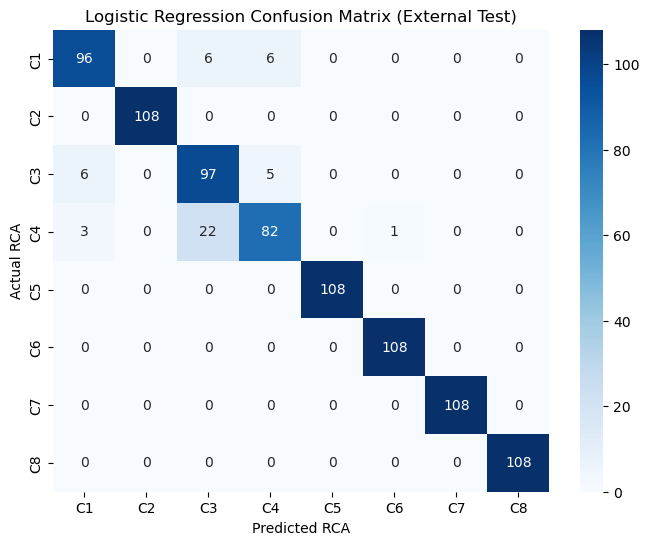

In [273]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(
    y_test_external,
    external_preds,
    labels=log_model.classes_
)

# -----------------------------
# Plot Heatmap
# -----------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix (External Test)"
)

plt.xlabel("Predicted RCA")
plt.ylabel("Actual RCA")

plt.show()

{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 129}

Best CV Score:
0.9428803016010336

- max_features: how many features the model is allowed to consider at each split of a tree
    - sqrt: if there are 50 features, every time it seas around square root of 50 which is around 7 features. 




### Fit Random Forest

In [274]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=129,
    max_depth=12,
    max_features="sqrt",
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

rf_preds = best_rf.predict(X_test)
rf_probs = best_rf.predict_proba(X_test)

### RF - Evaluation Metrics

In [275]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

rf_accuracy = accuracy_score(y_test, rf_preds)

rf_precision = precision_score(
    y_test,
    rf_preds,
    average="macro"
)

rf_recall = recall_score(
    y_test,
    rf_preds,
    average="macro"
)

rf_f1 = f1_score(
    y_test,
    rf_preds,
    average="macro"
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probs,
    multi_class="ovr",
    average="macro"
)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC-AUC:", rf_roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Results
Accuracy: 0.9416666666666667
Precision: 0.9467676039413602
Recall: 0.9404283650807981
F1: 0.942758233604504
ROC-AUC: 0.9960736446163263

Classification Report:
              precision    recall  f1-score   support

          C1       1.00      0.87      0.93        53
          C2       1.00      1.00      1.00        64
          C3       0.77      0.85      0.81        66
          C4       0.81      0.81      0.81        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.94       480
   macro avg       0.95      0.94      0.94       480
weighted avg       0.95      0.94      0.94       480



### 3. RF - Confusion Matrix

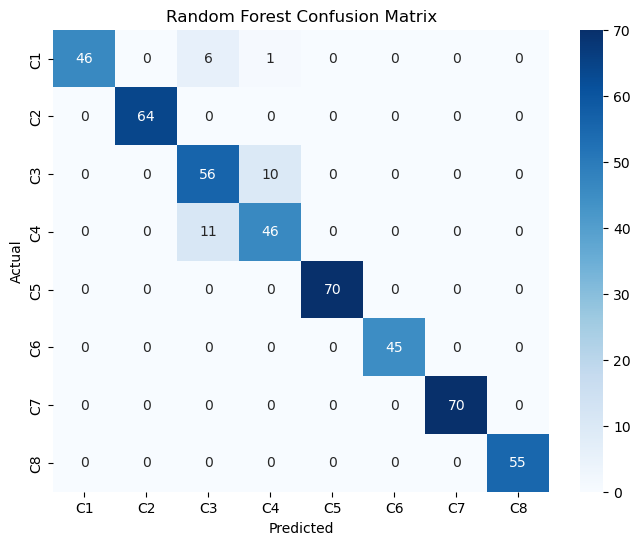

In [276]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(
    y_test,
    rf_preds,
    labels=best_rf.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [277]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

rf_youden_results = []

for cls in best_rf.classes_:
    y_true_binary = (y_test == cls).astype(int)
    y_pred_binary = (rf_preds == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    rf_youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

rf_youden_df = pd.DataFrame(rf_youden_results)

display(
    rf_youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
0,C1,0.868,1.000,0.868
2,C3,0.848,0.959,0.807
3,C4,0.807,0.974,0.781


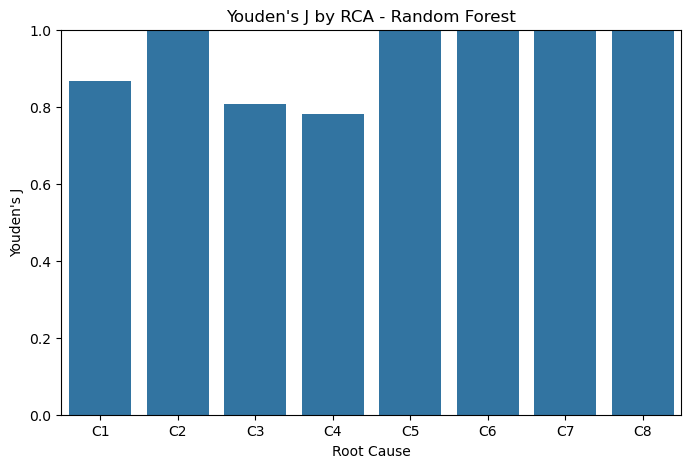

In [278]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rf_youden_df,
    x="RCA",
    y="Youden_J",
    order=best_rf.classes_
)

plt.title("Youden's J by RCA - Random Forest")
plt.xlabel("Root Cause")
plt.ylabel("Youden's J")
plt.ylim(0, 1)

plt.show()

### RF - Feature importances

In [279]:
rf_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    "importance",
    ascending=False
)

display(rf_feature_importance.head(20))

,feature,importance
36,same_mod30_ratio,0.072744
13,handover_rate,0.064336
35,same_mod30_count,0.063495
12,handover_count,0.058467
16,min_rsrp,0.046429
14,handover_count_low_tp,0.046059
9,avg_speed_low_tp,0.043645
7,max_speed,0.041266
28,pct_rb_below_160,0.038865
26,avg_rb_low_tp,0.038852


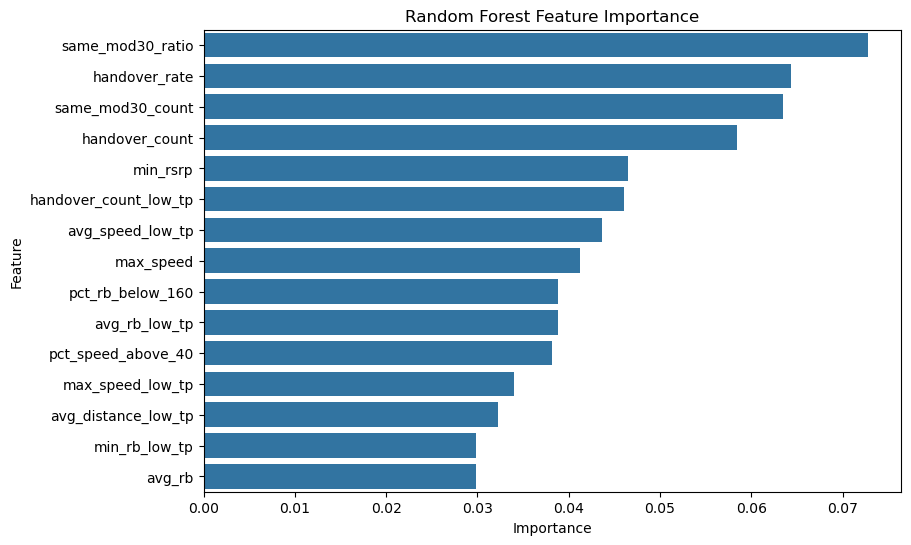

In [280]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=rf_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

- `pct_speed_above_40`: mobility dynamics strongly contribute to RCA differentiation.
- `min_rsrp` : Strongest radio quality signal.
- `pct_rb_below_160` : resource limitation

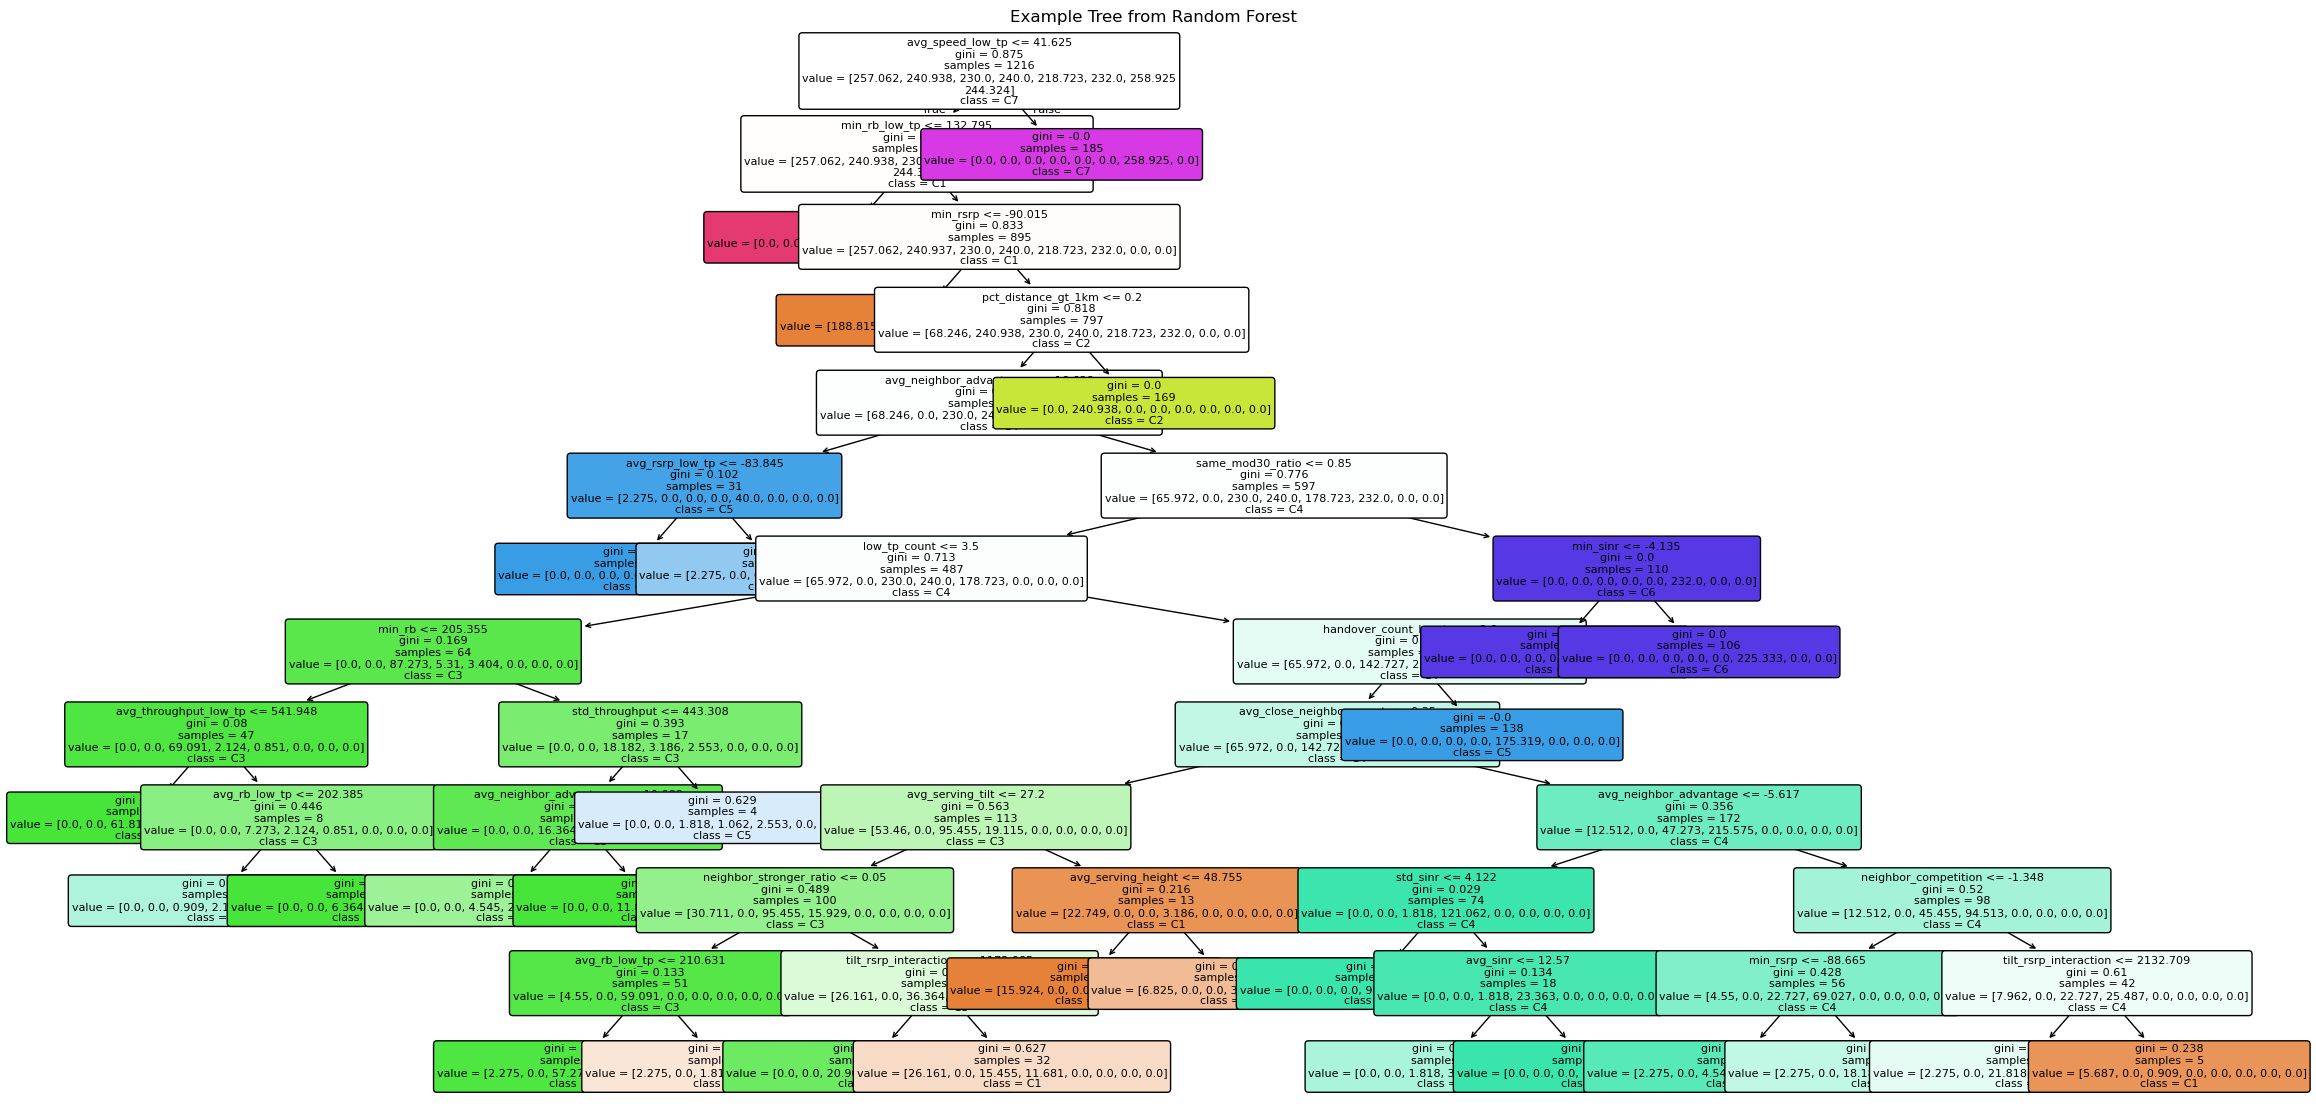

In [281]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(28,14))

plot_tree(
    best_rf.estimators_[0],
    feature_names=X_train.columns,
    class_names=best_rf.classes_,
    filled=True,
    rounded=True,
    max_depth=12,
    fontsize=8
)

plt.title("Example Tree from Random Forest ")
plt.show()

Early splits

```
pct_rb_below_160
same_mod30_ratio
handover_count
serving_distance
```

domain-informed ML.

### RF - ROC curve

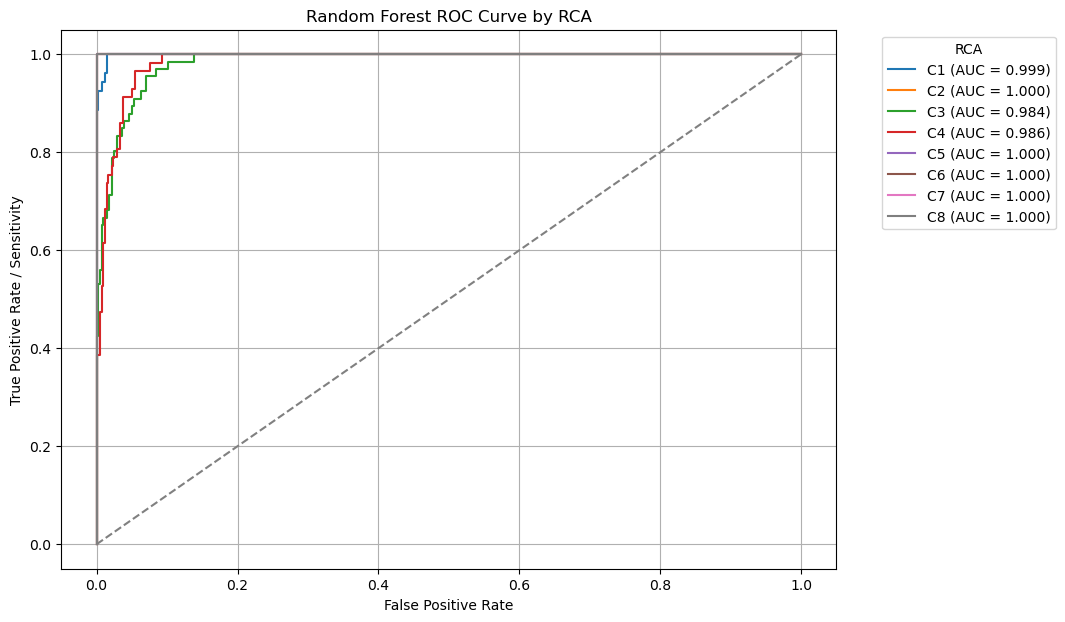

In [282]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = best_rf.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(10,7))

rf_roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)
    rf_roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("Random Forest ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### RF - Precision-Recall Curve — Multiclass One-vs-Rest

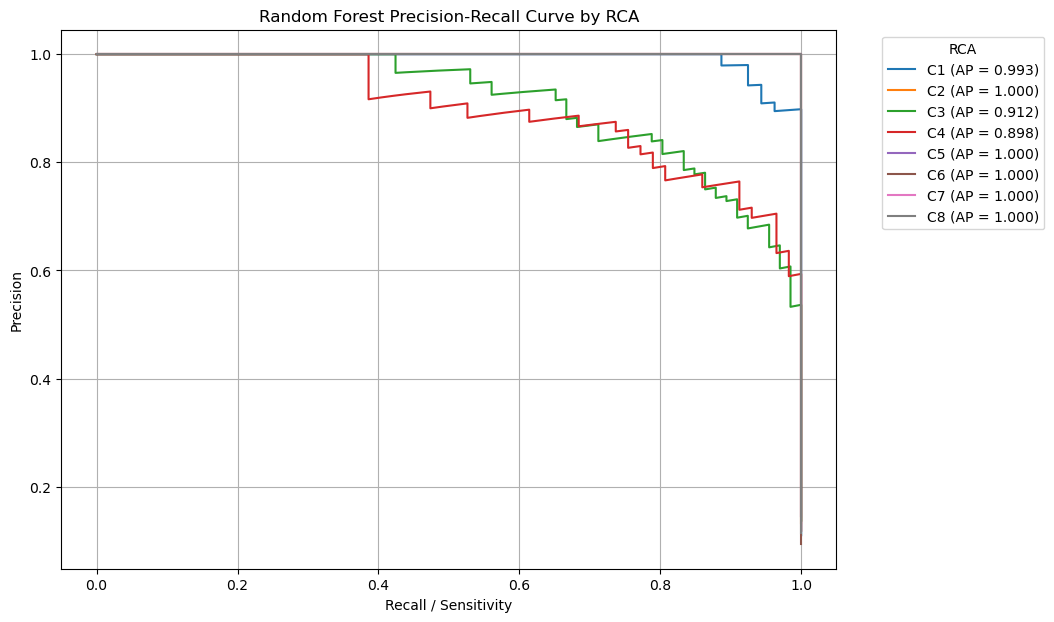

In [283]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

rf_pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    rf_pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("Random Forest Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### RF - Internal 5-Fold CV 

In [284]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

rf_cv_model = RandomForestClassifier(
    n_estimators=125,
    max_depth=13,
    max_features=None,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

rf_cv_results = cross_validate(
    rf_cv_model,
    X_encoded,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores = rf_cv_results[f"train_{metric}"]
    test_scores = rf_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {np.mean(train_scores):.3f} ({np.std(train_scores):.3f})")
    print(f"  Test : {np.mean(test_scores):.3f} ({np.std(test_scores):.3f})")
    print("-" * 40)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


accuracy
  Train: 0.984 (0.001)
  Test : 0.940 (0.003)
----------------------------------------
precision_macro
  Train: 0.984 (0.001)
  Test : 0.942 (0.003)
----------------------------------------
recall_macro
  Train: 0.983 (0.001)
  Test : 0.939 (0.002)
----------------------------------------
f1_macro
  Train: 0.984 (0.001)
  Test : 0.940 (0.002)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.996 (0.000)
----------------------------------------


In [285]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# X and y
# -----------------------------
X = ml_df.drop("answer", axis=1).copy()
y = ml_df["answer"].copy()

# -----------------------------
# Clean column dtypes
# -----------------------------

# Convert pandas string dtype / category dtype / object categorical columns safely
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].astype("object")

# Also make sure target is regular object/string
y = y.astype("object")

# -----------------------------
# Numeric / categorical columns
# -----------------------------
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# -----------------------------
# Preprocessing
# -----------------------------
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# -----------------------------
# Random Forest model
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=129,
    max_depth=12,
    max_features="sqrt",
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# Full pipeline
# -----------------------------
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_model)
    ]
)

# -----------------------------
# Internal CV
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

# -----------------------------
# Run cross validation
# -----------------------------
rf_cv_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True,
    error_score="raise"
)

# -----------------------------
# Print CV results
# -----------------------------
print("\nInternal 5-Fold Cross Validation Results for Random Forest")
print("=" * 60)

for metric in scoring.keys():
    train_scores = rf_cv_results[f"train_{metric}"]
    test_scores = rf_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {np.mean(train_scores):.3f} ({np.std(train_scores):.3f})")
    print(f"  Test : {np.mean(test_scores):.3f} ({np.std(test_scores):.3f})")
    print("-" * 60)

Numeric columns: ['avg_throughput', 'min_throughput', 'std_throughput', 'low_tp_count', 'low_tp_ratio', 'avg_throughput_low_tp', 'consecutive_low_tp_max', 'max_speed', 'pct_speed_above_40', 'avg_speed_low_tp', 'max_speed_low_tp', 'num_unique_serving_pci', 'handover_count', 'handover_rate', 'handover_count_low_tp', 'avg_rsrp', 'min_rsrp', 'avg_rsrp_low_tp', 'avg_sinr', 'min_sinr', 'avg_sinr_low_tp', 'std_sinr', 'pct_sinr_below_5', 'min_sinr_low_tp', 'avg_rb', 'min_rb', 'avg_rb_low_tp', 'min_rb_low_tp', 'pct_rb_below_160', 'avg_neighbor_advantage', 'max_neighbor_advantage', 'neighbor_stronger_ratio', 'avg_close_neighbor_count', 'overlap_ratio', 'same_mod30_exists', 'same_mod30_count', 'same_mod30_ratio', 'neighbor_competition', 'avg_serving_tilt', 'max_serving_tilt', 'avg_serving_beamwidth', 'avg_serving_height', 'avg_serving_distance_km', 'max_serving_distance_km', 'pct_distance_gt_1km', 'avg_distance_low_tp', 'tilt_rsrp_interaction']
Categorical columns: ['txrx_mode', 'antenna_model']


### Intepretation

#### Random Forest did NOT outperform Logistic Regression.
Engineered telecom features are so informative that even a linear model performs extremely well.

- Logistic Regression
    - Simple
    - Highly interpretable
    - Best macro F1
    - Strong generalization
- Random Forest
    - Slightly more complex
    - Mild overfitting
    - Similar performance
    - Validated telecom feature engineering


Increasing model complexity provided minimal improvement, suggesting that the engineered telecom KPIs already capture the majority of RCA signal.

### SHAP Intepretation

In [286]:
!pip install shap

  Using cached numpy-2.4.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl (5.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is

In [287]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

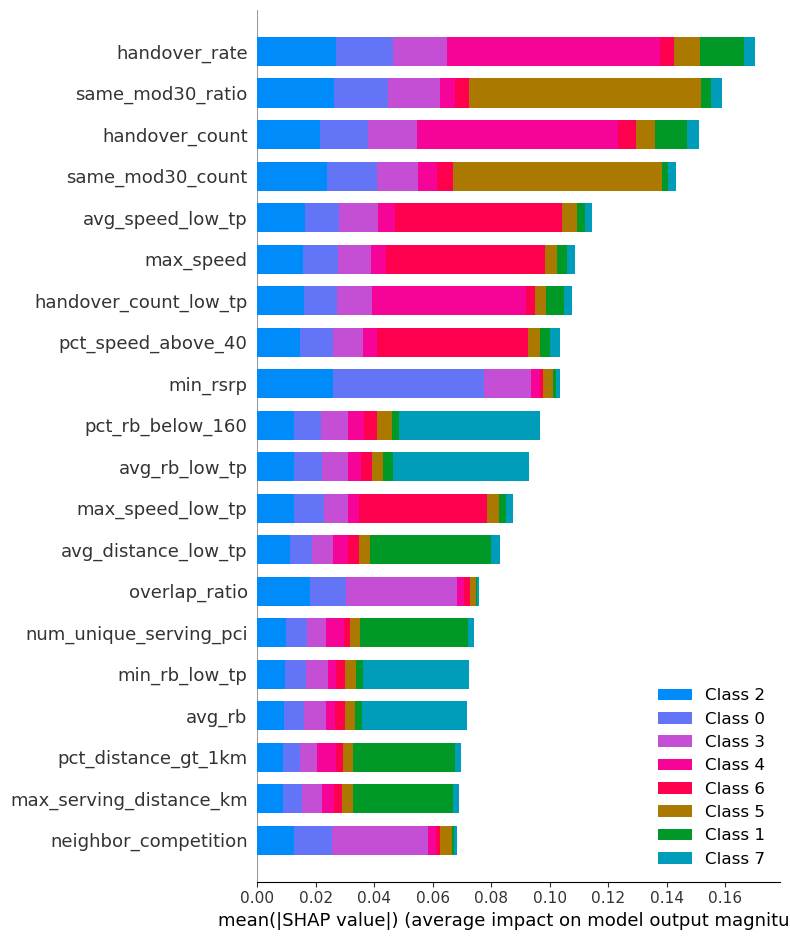

In [288]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

- pct_rb_below_160 is the strongest predictor
    - network resource pressure is globally predictive of failure modes.
- mobility dynamics strongly contribute to RCA differentiation.
    ```
    pct_speed_above_40
    handover_count
    handover_rate
    max_speed
    ```
- PCI conflict features were highly valuable
    - We engineered these features and model is heavily relies on them.

- Distance-based features matter strongly
    - overshooting-related RCA is strongly distance driven.
- Neighbor / overlap features matter, but less than expected

Global SHAP analysis revealed that RCA classification was primarily driven by engineered telecom KPIs related to resource availability, mobility, PCI conflict, and serving distance. The most influential feature was pct_rb_below_160, suggesting that radio resource scarcity plays a major role in distinguishing degradation mechanisms. Mobility-related variables (pct_speed_above_40, handover_count, handover_rate) and engineered PCI conflict indicators (same_mod30_ratio, same_mod30_count) also contributed strongly, validating the domain-informed feature engineering strategy. Interestingly, contextual network indicators were more influential than throughput alone, suggesting that RCA identification depends not only on performance degradation itself, but also on the surrounding radio and mobility conditions that drive it.

In [289]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("List length:", len(shap_values))
    print("Shape of first item:", shap_values[0].shape)
else:
    print("Shape:", shap_values.shape)

print("X_test shape:", X_test.shape)
print(best_rf.classes_)

<class 'numpy.ndarray'>
Shape: (480, 50, 8)
X_test shape: (480, 50)
['C1' 'C2' 'C3' 'C4' 'C5' 'C6' 'C7' 'C8']


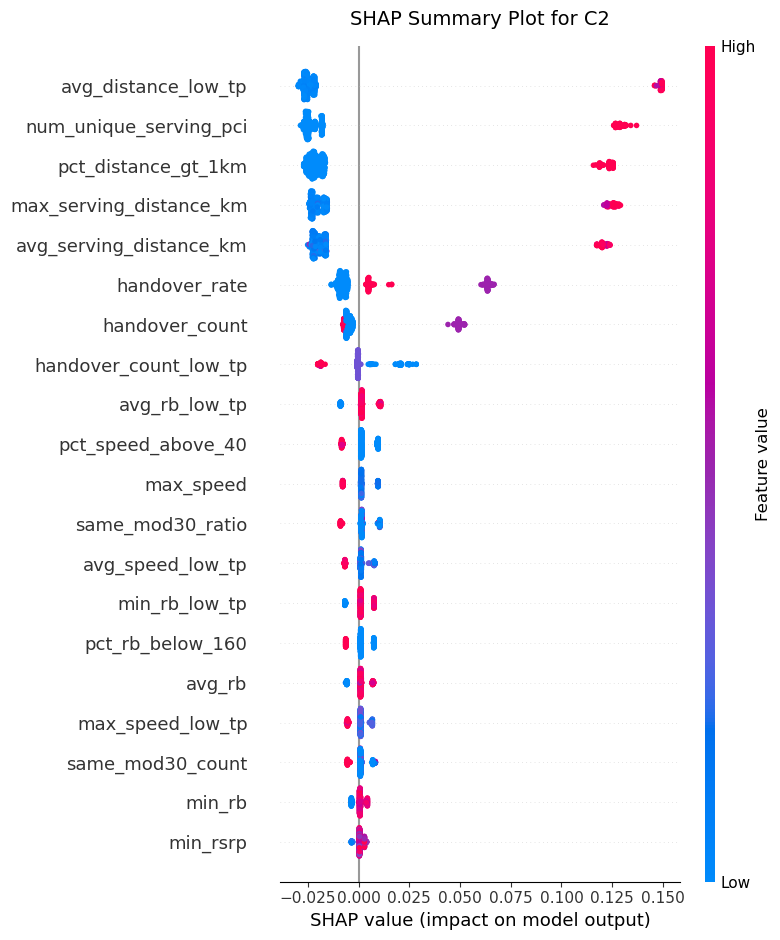

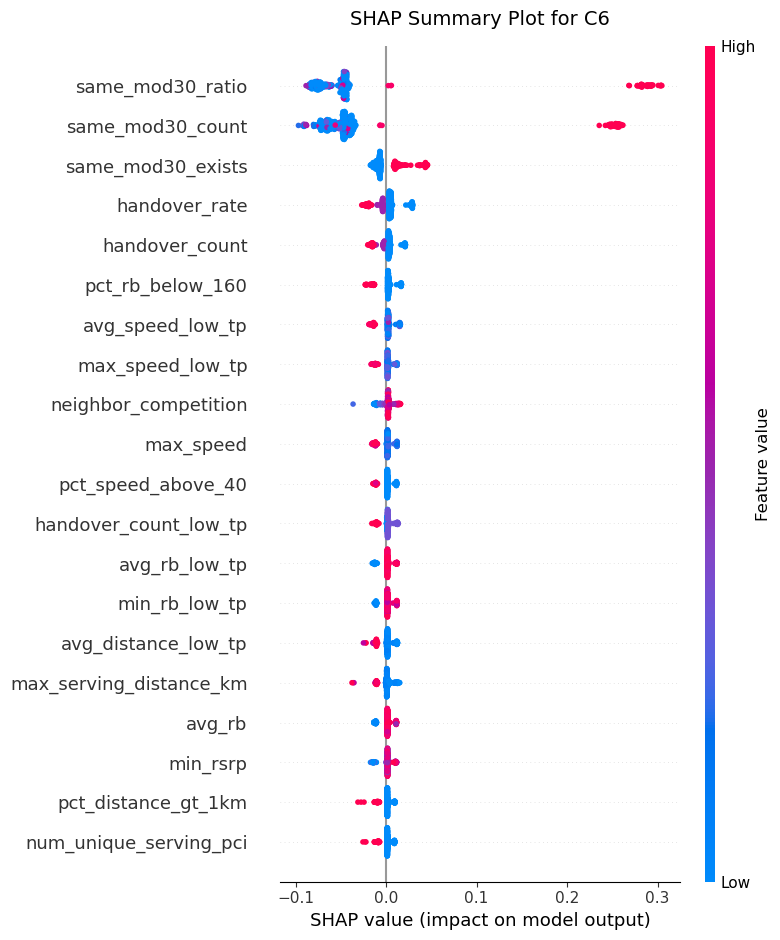

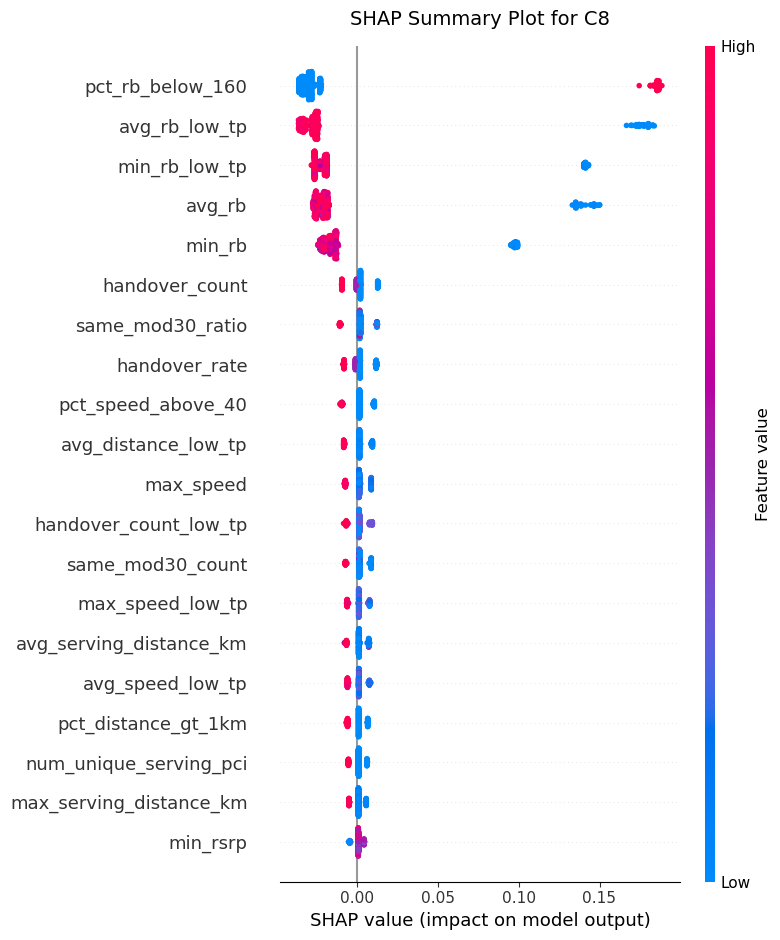

In [290]:
import matplotlib.pyplot as plt

for class_name in ["C2", "C6", "C8"]:
    
    class_idx = list(best_rf.classes_).index(class_name)

    if isinstance(shap_values, list):
        shap_class = shap_values[class_idx]
    else:
        shap_class = shap_values[:, :, class_idx]

    plt.figure(figsize=(8,6))

    shap.summary_plot(
        shap_class,
        X_test,
        feature_names=X_test.columns,
        show=False
    )

    plt.title(
        f"SHAP Summary Plot for {class_name}",
        fontsize=14,
        pad=15
    )

    plt.tight_layout()
    plt.show()

##### SHAP intepretation for C2
Class-specific SHAP analysis for **C2 (Coverage Overshooting)** revealed that distance-related KPIs were the strongest drivers of model prediction. Features such as `max_serving_distance_km`, `avg_serving_distance_km`, `pct_distance_gt_1km`, and `avg_distance_low_tp` exhibited the highest SHAP impact, with larger values substantially increasing the likelihood of C2 classification. This finding strongly aligns with telecom expectations, as overshooting scenarios occur when users are served by distant cells beyond optimal coverage range. Interestingly, RB scarcity (`pct_rb_below_160`) contributed negatively, suggesting that C2 is primarily a coverage issue rather than a resource limitation problem.

##### SHAP intepretation for C6 - PCI mod 30 conflicts causing interference
Class-specific SHAP analysis for C6 (PCI Conflict) revealed that engineered PCI conflict indicators (same_mod30_ratio and same_mod30_count) were the strongest drivers of model prediction. Higher values of these features substantially increased the likelihood of C6 classification, confirming that modulo-30 PCI overlap is a defining signal of interference-related degradation. In contrast, distance-related features contributed negatively, suggesting that C6 is operationally distinct from overshooting scenarios (C2). These findings strongly validate the domain-informed feature engineering strategy used to capture PCI conflict behavior. Those two same_mod30_ratio and same_mod30_count strong features are features that were manually engineered which indicates huge win.

##### SHAP intepretation for C8 - PCI mod 30 conflicts causing interference
Class-specific SHAP analysis for C8 revealed that pct_rb_below_160 was by far the strongest driver of model prediction, with higher values substantially increasing the likelihood of C8 classification. This finding strongly supports the interpretation of C8 as a resource limitation or congestion-related RCA, where insufficient radio resources become the defining network characteristic. In contrast, distance-based features and PCI conflict indicators contributed minimally, suggesting that C8 is operationally distinct from overshooting (C2) and PCI conflict (C6) scenarios. Overall, the SHAP analysis validates that the model differentiates RCA classes using engineering-consistent telecom behaviors rather than arbitrary statistical patterns.

### Random Forest External Cross Validation

In [291]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Refit Random Forest on FULL train.json
# -----------------------------

X_full_train = X_encoded.copy()
y_full_train = y.copy()

best_rf = RandomForestClassifier(
    n_estimators=129,
    max_depth=12,
    max_features="sqrt",
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(
    X_full_train,
    y_full_train
)

print("Final Random Forest model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

Final Random Forest model refit on 100% of train.json
Training shape: (2400, 50)


In [292]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# If X_test_external is already prepared from Logistic Regression BEFORE scaling,
# use that version directly.

# Predict on external test set
rf_external_preds = best_rf.predict(X_test_external)
rf_external_probs = best_rf.predict_proba(X_test_external)

# Accuracy
print("Random Forest External Test Accuracy:")
print(accuracy_score(y_test_external, rf_external_preds))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, rf_external_preds))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_external, rf_external_preds))

# Metrics table
rf_report = classification_report(
    y_test_external,
    rf_external_preds,
    output_dict=True
)

rf_metrics_df = pd.DataFrame(rf_report).transpose().round(3)
rf_metrics_df

Random Forest External Test Accuracy:
0.9375

Confusion Matrix:
[[ 86   0  15   7   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  1   0  94  13   0   0   0   0]
 [  2   0  16  90   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.97      0.80      0.87       108
          C2       1.00      1.00      1.00       108
          C3       0.75      0.87      0.81       108
          C4       0.82      0.83      0.83       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.94       864
   macro avg       0.94      0.94      0.94       864
weighted avg       0.94      0.94  

,precision,recall,f1-score,support
C1,0.966,0.796,0.873,108.000
C2,1.000,1.000,1.000,108.000
C3,0.752,0.870,0.807,108.000
C4,0.818,0.833,0.826,108.000
C5,1.000,1.000,1.000,108.000
C6,1.000,1.000,1.000,108.000
C7,1.000,1.000,1.000,108.000
C8,1.000,1.000,1.000,108.000
accuracy,0.938,0.938,0.938,0.938
macro avg,0.942,0.938,0.938,864.000


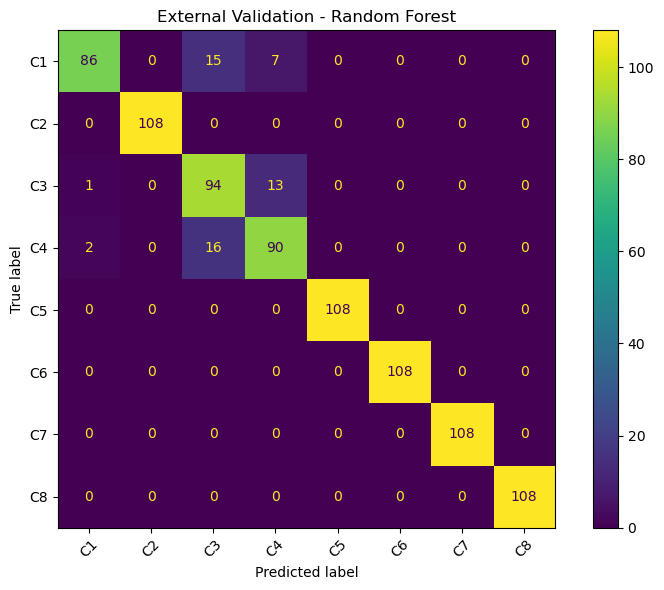

In [293]:
cm = confusion_matrix(y_test_external, rf_external_preds)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_rf.classes_
)

disp.plot(ax=ax)

plt.title("External Validation - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. XGBoost


In [294]:
#!pip install xgboost

{'colsample_bytree': 1.0, 'learning_rate': 0.15, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1.0}

Best CV Macro F1:
0.9578418411975405




### Fit XGBoost Model with best Parameters

In [295]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, f1_score

# -----------------------------
# X and y
# -----------------------------

X = X_encoded.copy()
y = ml_df["answer"]

# -----------------------------
# Encode target labels
# C1, C2, ... -> 0, 1, ...
# -----------------------------

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(original, "->", encoded)

# -----------------------------
# Train/Test split
# -----------------------------
# If you already have X_train, X_test, y_train, y_test from before,
# you can skip this and just encode y_train/y_test.
# But this keeps it clean.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=1.0,
    learning_rate=0.15,
    max_depth=5,
    n_estimators=150,
    subsample=1.0,
    random_state=42,
    n_jobs=1
)

# Train
best_xgb.fit(X_train, y_train)

# Predict
xgb_preds_encoded = best_xgb.predict(X_test)
xgb_probs = best_xgb.predict_proba(X_test)

# Convert back to C1–C8 labels
xgb_pred_labels = label_encoder.inverse_transform(
    xgb_preds_encoded.astype(int)
)


Class mapping:
C1 -> 0
C2 -> 1
C3 -> 2
C4 -> 3
C5 -> 4
C6 -> 5
C7 -> 6
C8 -> 7


In [296]:
y_test_labels = label_encoder.inverse_transform(y_test)
xgb_pred_labels = label_encoder.inverse_transform(xgb_preds)

### XGBoost Evaluation Metrics

In [297]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Use encoded test labels and encoded predictions
xgb_accuracy = accuracy_score(y_test, xgb_preds_encoded)

xgb_precision = precision_score(
    y_test,
    xgb_preds_encoded,
    average="macro"
)

xgb_recall = recall_score(
    y_test,
    xgb_preds_encoded,
    average="macro"
)

xgb_f1 = f1_score(
    y_test,
    xgb_preds_encoded,
    average="macro"
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probs,
    multi_class="ovr",
    average="macro"
)

print("XGBoost Results")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1:", xgb_f1)
print("ROC-AUC:", xgb_roc_auc)

print("\nClassification Report:")
print(
    classification_report(
        y_test_labels,
        xgb_pred_labels
    )
)

XGBoost Results
Accuracy: 0.95625
Precision: 0.9589850019155303
Recall: 0.9549140862447715
F1: 0.9564165837441334
ROC-AUC: 0.9974431095013048

Classification Report:
              precision    recall  f1-score   support

          C1       0.98      0.91      0.94        53
          C2       1.00      1.00      1.00        64
          C3       0.82      0.91      0.86        66
          C4       0.87      0.82      0.85        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.96       480
   macro avg       0.96      0.95      0.96       480
weighted avg       0.96      0.96      0.96       480



### XGBoost - Confusion Metrics

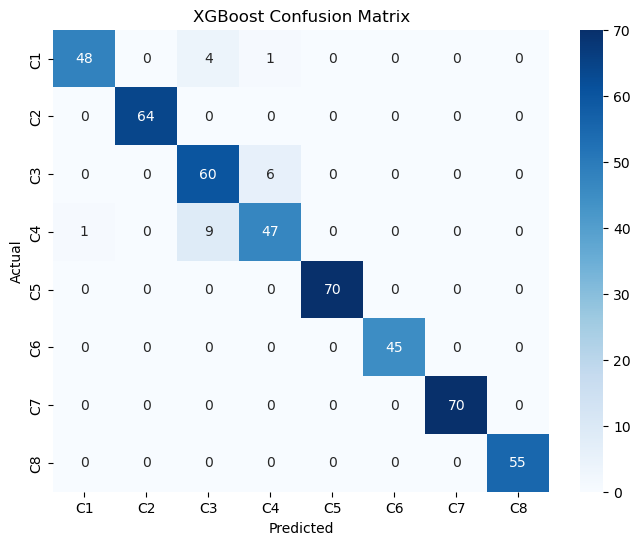

In [298]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_cm = confusion_matrix(
    y_test_labels,
    xgb_pred_labels,
    labels=label_encoder.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [299]:
import pandas as pd
from sklearn.metrics import confusion_matrix

xgb_youden_results = []

for cls in label_encoder.classes_:
    y_true_binary = (y_test_labels == cls).astype(int)
    y_pred_binary = (xgb_pred_labels == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    xgb_youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

xgb_youden_df = pd.DataFrame(xgb_youden_results)

display(
    xgb_youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
0,C1,0.906,0.998,0.903
2,C3,0.909,0.969,0.878
3,C4,0.825,0.983,0.808


### XGBoost - Feature Importance

In [300]:
xgb_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "importance",
    ascending=False
)

display(xgb_feature_importance.head(20))

,feature,importance
11,num_unique_serving_pci,0.237656
12,handover_count,0.149833
35,same_mod30_count,0.130872
7,max_speed,0.125267
24,avg_rb,0.092346
16,min_rsrp,0.055113
3,low_tp_count,0.029474
33,overlap_ratio,0.021889
31,neighbor_stronger_ratio,0.020893
14,handover_count_low_tp,0.016000


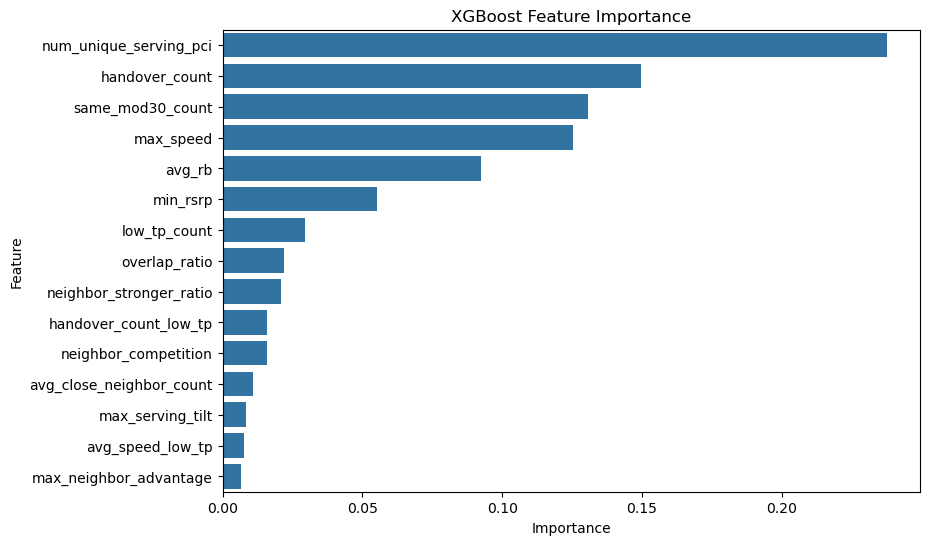

In [301]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=xgb_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### XGBoost - ROC Curve — Multiclass One-vs-Rest

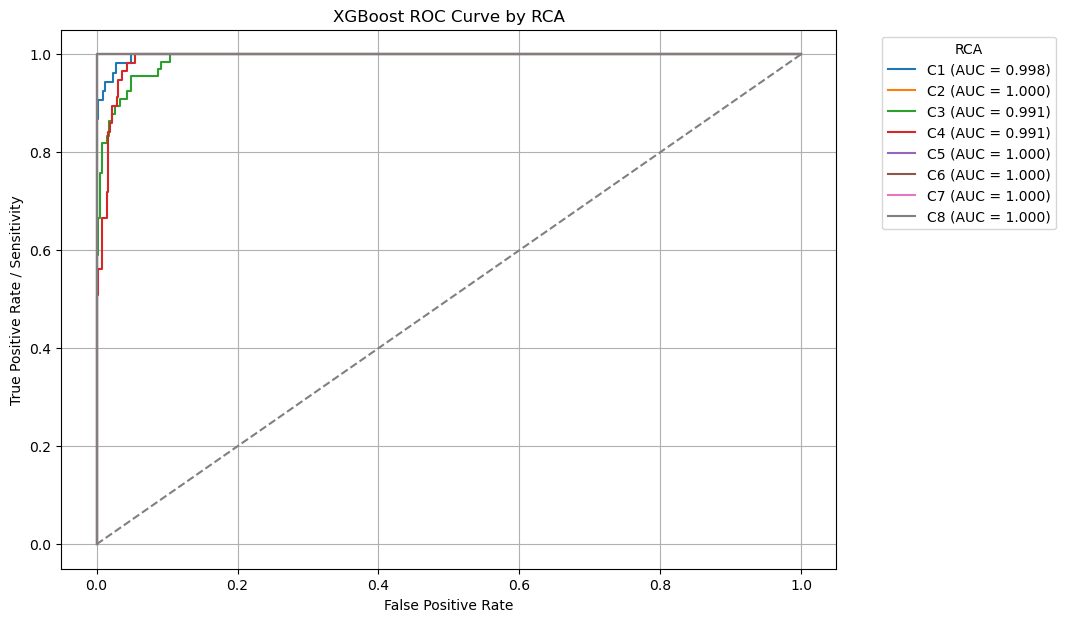

In [302]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = label_encoder.classes_

y_test_bin = label_binarize(
    y_test_labels,
    classes=classes
)

plt.figure(figsize=(10,7))

xgb_roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)
    xgb_roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("XGBoost ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### XGBoost Precision-Recall Curve — Multiclass One-vs-Rest

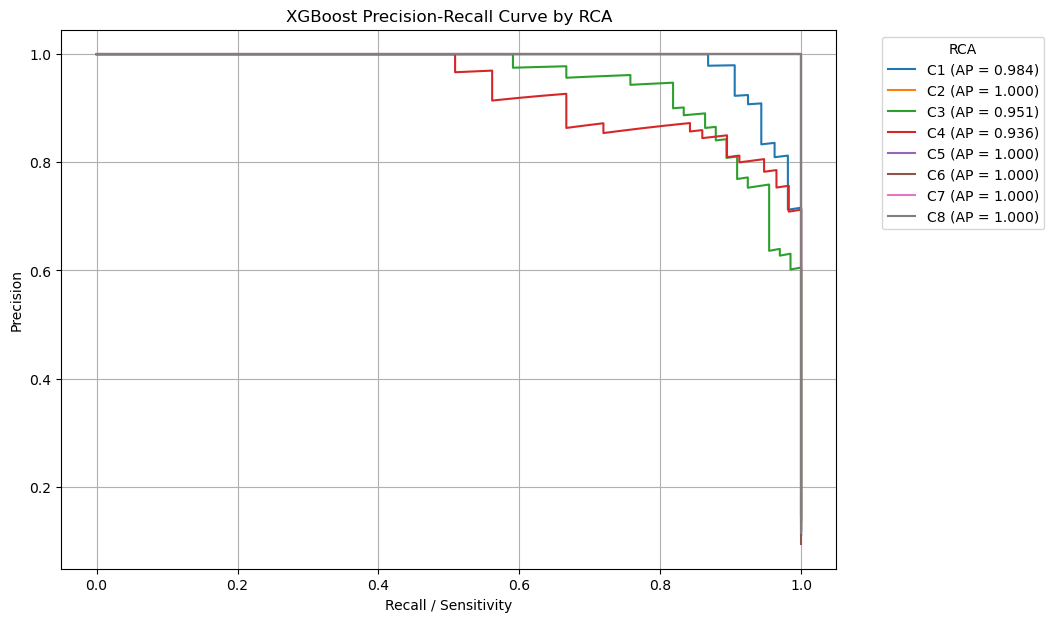

In [303]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

xgb_pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        xgb_probs[:, i]
    )

    xgb_pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("XGBoost Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

### Internal 5-fold Cross Validaton

num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    colsample_bytree=1.0,
    learning_rate=0.15,
    max_depth=5,
    n_estimators=150,
    subsample=1.0,
    random_state=42,
    n_jobs=1

In [304]:
from sklearn.model_selection import StratifiedKFold, cross_validate

xgb_cv_model = XGBClassifier(
    objective="multi:softprob",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=5,
    eval_metric='mlogloss'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

xgb_cv_results = cross_validate(
    xgb_cv_model,
    X_encoded,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores = xgb_cv_results[f"train_{metric}"]
    test_scores = xgb_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {train_scores.mean():.3f} ({train_scores.std():.3f})")
    print(f"  Test : {test_scores.mean():.3f} ({test_scores.std():.3f})")
    print("-" * 40)

accuracy
  Train: 1.000 (0.000)
  Test : 0.951 (0.006)
----------------------------------------
precision_macro
  Train: 1.000 (0.000)
  Test : 0.953 (0.005)
----------------------------------------
recall_macro
  Train: 1.000 (0.000)
  Test : 0.950 (0.005)
----------------------------------------
f1_macro
  Train: 1.000 (0.000)
  Test : 0.951 (0.006)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.997 (0.000)
----------------------------------------


| Model               |  Accuracy | Precision Macro | Recall Macro |  F1 Macro |   ROC-AUC |
| ------------------- | --------: | --------------: | -----------: | --------: | --------: |
| Logistic Regression |     0.946 |           0.946 |        0.945 |     0.945 |     0.996 |
| Random Forest       |     0.944 |           0.946 |        0.943 |     0.944 |     0.996 |
| **XGBoost**         | **0.954** |       **0.957** |    **0.953** | **0.954** | **0.998** |


**Key observations:**

XGBoost improved overall performance, especially Macro F1: 0.954 vs. 0.945 for Logistic Regression.
C2, C5, C6, C7, and C8 were perfectly classified, which matches your EDA and SHAP findings.
C3 and C4 are still the hardest classes, but XGBoost improved C3 recall to 0.894 and C3 F1 to 0.86.
The confusion is still mainly C3 ↔ C4, suggesting these two RCA types have genuinely overlapping KPI signatures.
CV test Macro F1 = 0.955, which matches the holdout result very well.
Train CV = 1.000, so XGBoost is fitting training data perfectly, but the stable test CV suggests performance is still strong. I would describe this as high model capacity with good validation performance, not a failure.

XGBoost achieved the strongest overall performance, suggesting that nonlinear boosted trees can capture additional RCA structure beyond Logistic Regression and Random Forest, especially for more ambiguous classes such as C3 and C4. However, the remaining C3/C4 confusion indicates that these RCA mechanisms may share similar telecom KPI patterns.

### XGBoost - External Cross Valdation

In [305]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode RCA labels using FULL train.json
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for original, encoded in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(original, "->", encoded)

# -----------------------------
# Refit XGBoost on FULL train.json
# -----------------------------

X_full_train = X_encoded.copy()
y_full_train = y_encoded.copy()

best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=5,
    eval_metric='mlogloss'
)

best_xgb.fit(
    X_train, y_train,
    
)

print("Final XGBoost model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

Class mapping:
C1 -> 0
C2 -> 1
C3 -> 2
C4 -> 3
C5 -> 4
C6 -> 5
C7 -> 6
C8 -> 7
Final XGBoost model refit on 100% of train.json
Training shape: (2400, 50)


In [306]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# External X data should already be prepared:
# - one-hot encoded
# - reindexed to X_train.columns
# - median imputed
# - NOT scaled

X_test_external_xgb = X_test_external.copy()

# Encode external y labels using the SAME label encoder
y_test_external_encoded = label_encoder.transform(y_test_external)

# Predict
xgb_external_preds_encoded = best_xgb.predict(X_test_external_xgb)
xgb_external_probs = best_xgb.predict_proba(X_test_external_xgb)

# Convert predictions back to original labels
xgb_external_preds = label_encoder.inverse_transform(
    xgb_external_preds_encoded.astype(int)
)

# Evaluation
print("XGBoost External Test Accuracy:")
print(accuracy_score(y_test_external, xgb_external_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, xgb_external_preds))

print("\nClassification Report:")
print(classification_report(y_test_external, xgb_external_preds))

XGBoost External Test Accuracy:
0.9166666666666666

Confusion Matrix:
[[ 85   0   9   3   0   0   0  11]
 [  0 108   0   0   0   0   0   0]
 [  2   0  94   3   0   0   0   9]
 [  2   0  17  73   0   0   0  16]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.96      0.79      0.86       108
          C2       1.00      1.00      1.00       108
          C3       0.78      0.87      0.82       108
          C4       0.92      0.68      0.78       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       0.75      1.00      0.86       108

    accuracy                           0.92       864
   macro avg       0.93      0.92      0.92       864
weighted avg       0.93      

In [307]:
xgb_report = classification_report(
    y_test_external,
    xgb_external_preds,
    output_dict=True
)

xgb_metrics_df = pd.DataFrame(xgb_report).transpose().round(3)
xgb_metrics_df

,precision,recall,f1-score,support
C1,0.955,0.787,0.863,108.000
C2,1.000,1.000,1.000,108.000
C3,0.783,0.870,0.825,108.000
C4,0.924,0.676,0.781,108.000
C5,1.000,1.000,1.000,108.000
C6,1.000,1.000,1.000,108.000
C7,1.000,1.000,1.000,108.000
C8,0.750,1.000,0.857,108.000
accuracy,0.917,0.917,0.917,0.917
macro avg,0.927,0.917,0.916,864.000


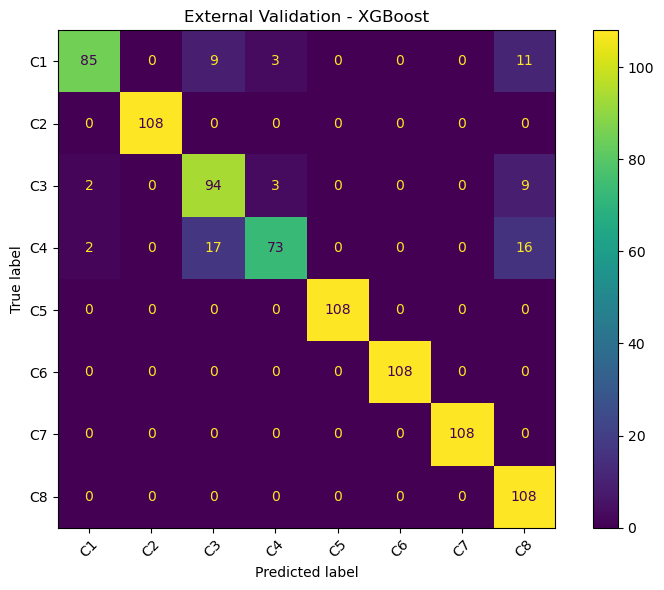

In [308]:
cm = confusion_matrix(y_test_external, xgb_external_preds)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax)

plt.title("External Validation - XGBoost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Light GBM

### Light GBM - Grid Search

In [309]:
#!pip install lightgbm

Best Parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 250, 'num_leaves': 63, 'subsample': 0.7}

Best CV Macro F1:
0.9581297910488621

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.17, 'max_depth': 7, 'n_estimators': 260, 'num_leaves': 61, 'subsample': 0.6}

Best CV Macro F1:
0.9590999360155044

{'colsample_bytree': 0.7, 'learning_rate': 0.17, 'max_depth': 7, 'n_estimators': 250, 'num_leaves': 61, 'subsample': 0.6}

Best CV Macro F1:
0.955224592611349

In [310]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

best_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    colsample_bytree=0.7,
    learning_rate=0.17,
    max_depth=7,
    n_estimators=250,
    num_leaves=61,
    subsample=0.6,
    random_state=42,
    n_jobs=1,
    verbose=-1

)
best_lgbm.fit(X_train, y_train)

lgbm_preds = best_lgbm.predict(X_test)
lgbm_probs = best_lgbm.predict_proba(X_test)

# Convert labels back to C1–C8
y_test_labels = label_encoder.inverse_transform(y_test)
lgbm_pred_labels = label_encoder.inverse_transform(lgbm_preds)

### Light GBM - Metrics

In [311]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

lgbm_accuracy = accuracy_score(y_test, lgbm_preds)
lgbm_precision = precision_score(y_test, lgbm_preds, average="macro")
lgbm_recall = recall_score(y_test, lgbm_preds, average="macro")
lgbm_f1 = f1_score(y_test, lgbm_preds, average="macro")
lgbm_roc_auc = roc_auc_score(
    y_test,
    lgbm_probs,
    multi_class="ovr",
    average="macro"
)

print("LightGBM Results")
print("Accuracy:", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall:", lgbm_recall)
print("F1:", lgbm_f1)
print("ROC-AUC:", lgbm_roc_auc)

print("\nClassification Report:")
print(classification_report(y_test_labels, lgbm_pred_labels))

LightGBM Results
Accuracy: 0.95
Precision: 0.9519132653061224
Recall: 0.9492322680629532
F1: 0.950282645347065
ROC-AUC: 0.996779386230254

Classification Report:
              precision    recall  f1-score   support

          C1       0.98      0.91      0.94        53
          C2       1.00      1.00      1.00        64
          C3       0.81      0.86      0.84        66
          C4       0.84      0.82      0.83        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       0.98      1.00      0.99        55

    accuracy                           0.95       480
   macro avg       0.95      0.95      0.95       480
weighted avg       0.95      0.95      0.95       480



### Light GBM - Confusion Matrix

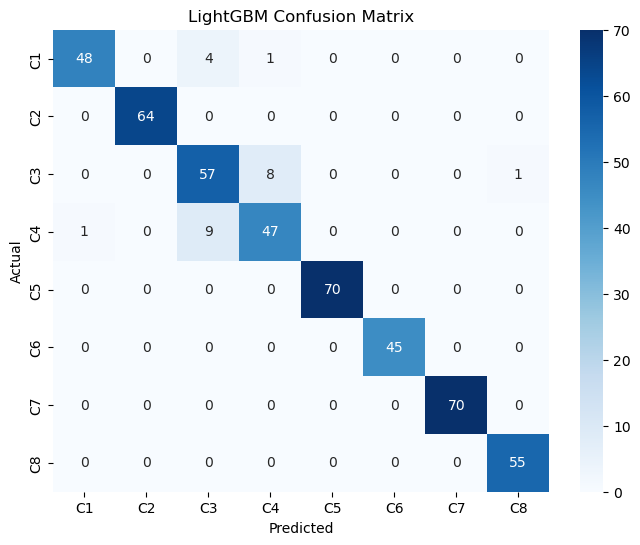

In [312]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

lgbm_cm = confusion_matrix(
    y_test_labels,
    lgbm_pred_labels,
    labels=label_encoder.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    lgbm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Light GBM -  Sensitivity, specificity, Youden’s J

In [313]:
lgbm_youden_results = []

for cls in label_encoder.classes_:
    y_true_binary = (y_test_labels == cls).astype(int)
    y_pred_binary = (lgbm_pred_labels == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    lgbm_youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

lgbm_youden_df = pd.DataFrame(lgbm_youden_results)

display(
    lgbm_youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,0.998,0.998
0,C1,0.906,0.998,0.903
2,C3,0.864,0.969,0.832
3,C4,0.825,0.979,0.803


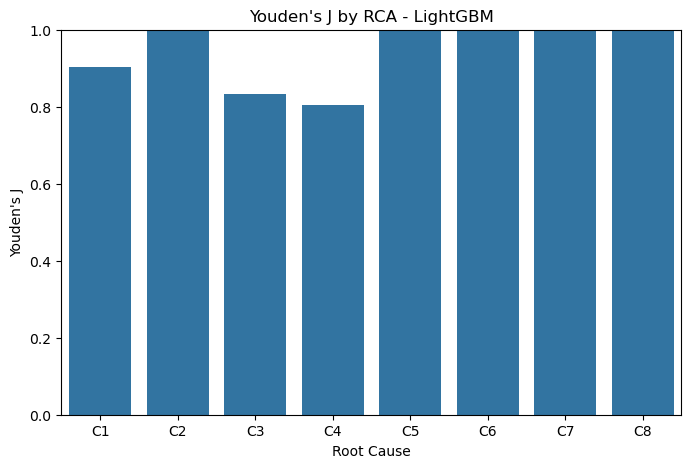

In [314]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=lgbm_youden_df,
    x="RCA",
    y="Youden_J",
    order=label_encoder.classes_
)

plt.title("Youden's J by RCA - LightGBM")
plt.xlabel("Root Cause")
plt.ylabel("Youden's J")
plt.ylim(0, 1)
plt.show()

### Light GBM - Feature importance

In [315]:
lgbm_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_lgbm.feature_importances_
})

lgbm_feature_importance = lgbm_feature_importance.sort_values(
    "importance",
    ascending=False
)

display(lgbm_feature_importance.head(20))

,feature,importance
37,neighbor_competition,1291
5,avg_throughput_low_tp,984
30,max_neighbor_advantage,919
29,avg_neighbor_advantage,802
32,avg_close_neighbor_count,737
2,std_throughput,732
17,avg_rsrp_low_tp,718
1,min_throughput,704
0,avg_throughput,693
16,min_rsrp,612


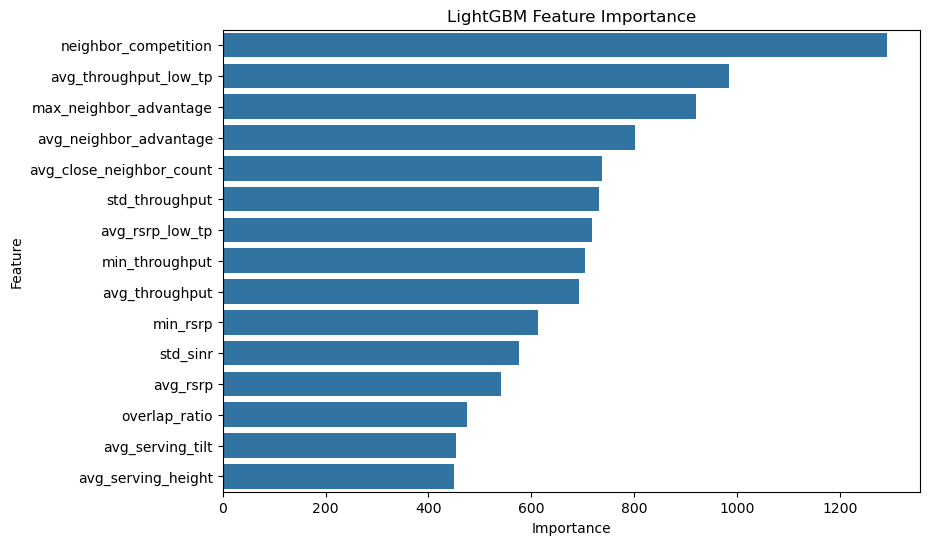

In [316]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=lgbm_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Light GBM - ROC curve

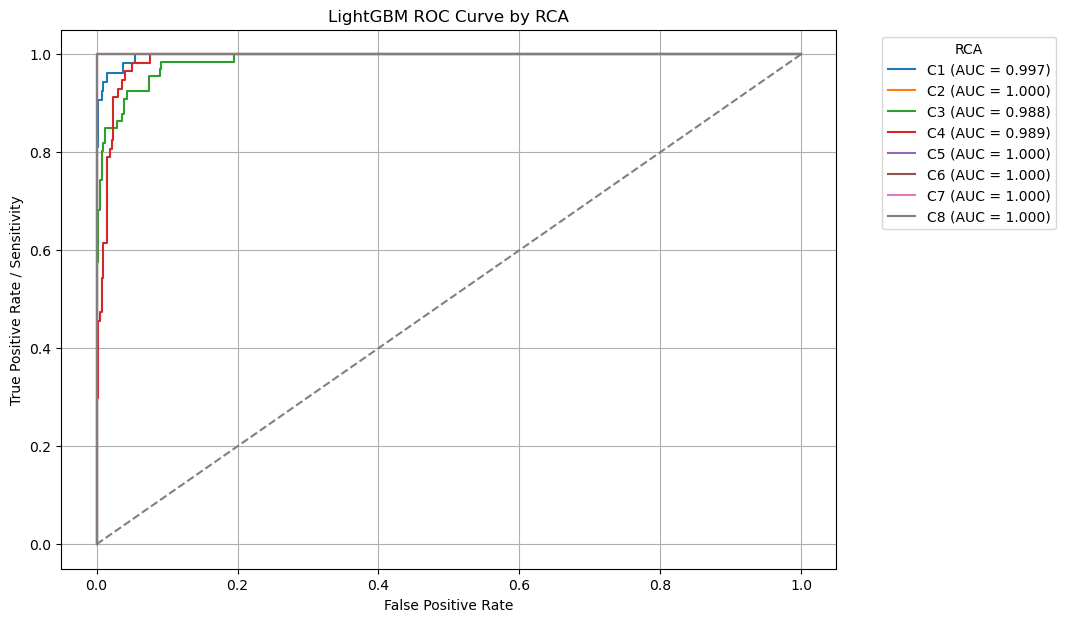

In [317]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = label_encoder.classes_

y_test_bin = label_binarize(
    y_test_labels,
    classes=classes
)

plt.figure(figsize=(10,7))

lgbm_roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        lgbm_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)
    lgbm_roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("LightGBM ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

### Light GBM - Precision-Recall Curve

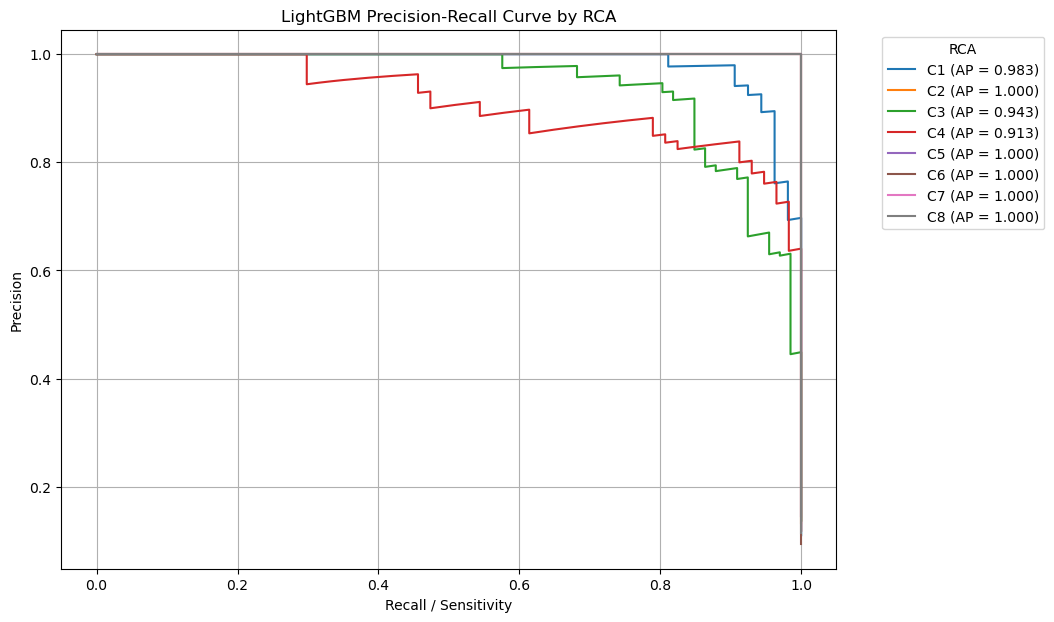

In [318]:
### Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

lgbm_pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        lgbm_probs[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        lgbm_probs[:, i]
    )

    lgbm_pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("LightGBM Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

### Light GBM - Internal CV

In [319]:
from sklearn.model_selection import cross_validate

lgbm_cv_model = LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    colsample_bytree=0.7,
    learning_rate=0.17,
    max_depth=7,
    n_estimators=250,
    num_leaves=61,
    subsample=0.6,
    random_state=42,
    n_jobs=1,
    verbose=-1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

lgbm_cv_results = cross_validate(
    lgbm_cv_model,
    X_encoded,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores = lgbm_cv_results[f"train_{metric}"]
    test_scores = lgbm_cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {train_scores.mean():.3f} ({train_scores.std():.3f})")
    print(f"  Test : {test_scores.mean():.3f} ({test_scores.std():.3f})")
    print("-" * 40)

accuracy
  Train: 1.000 (0.000)
  Test : 0.955 (0.005)
----------------------------------------
precision_macro
  Train: 1.000 (0.000)
  Test : 0.957 (0.005)
----------------------------------------
recall_macro
  Train: 1.000 (0.000)
  Test : 0.954 (0.004)
----------------------------------------
f1_macro
  Train: 1.000 (0.000)
  Test : 0.955 (0.005)
----------------------------------------
roc_auc_ovr
  Train: 1.000 (0.000)
  Test : 0.997 (0.000)
----------------------------------------


### Light GBM - External cross validation

In [320]:
from lightgbm import LGBMClassifier

# -----------------------------
# Refit LightGBM on FULL train.json
# -----------------------------

X_full_train = X_encoded.copy()
y_full_train = y_encoded.copy()

best_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    colsample_bytree=0.7,
    learning_rate=0.17,
    max_depth=7,
    n_estimators=250,
    num_leaves=61,
    subsample=0.6,
    random_state=42,
    n_jobs=1,
    verbose=-1

)



best_lgbm.fit(
    X_full_train,
    y_full_train
)

print("Final LightGBM model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

Final LightGBM model refit on 100% of train.json
Training shape: (2400, 50)


In [321]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Predict numeric labels
lgbm_external_preds_encoded = best_lgbm.predict(X_test_external)
lgbm_external_probs = best_lgbm.predict_proba(X_test_external)

# Convert numeric predictions back to original RCA labels
lgbm_external_preds = label_encoder.inverse_transform(
    lgbm_external_preds_encoded.astype(int)
)

# Evaluation
print("LightGBM External Test Accuracy:")
print(accuracy_score(y_test_external, lgbm_external_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_external, lgbm_external_preds))

print("\nClassification Report:")
print(classification_report(y_test_external, lgbm_external_preds))

LightGBM External Test Accuracy:
0.9513888888888888

Confusion Matrix:
[[ 92   0  12   4   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  2   0 102   4   0   0   0   0]
 [  4   0  16  88   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.94      0.85      0.89       108
          C2       1.00      1.00      1.00       108
          C3       0.78      0.94      0.86       108
          C4       0.92      0.81      0.86       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.95       864
   macro avg       0.96      0.95      0.95       864
weighted avg       0.96     

In [322]:
# Metrics table for external cross validation
lgbm_report = classification_report(
    y_test_external,
    lgbm_external_preds,
    output_dict=True
)

lgbm_metrics_df = pd.DataFrame(lgbm_report).transpose().round(3)
lgbm_metrics_df

,precision,recall,f1-score,support
C1,0.939,0.852,0.893,108.000
C2,1.000,1.000,1.000,108.000
C3,0.785,0.944,0.857,108.000
C4,0.917,0.815,0.863,108.000
C5,1.000,1.000,1.000,108.000
C6,1.000,1.000,1.000,108.000
C7,1.000,1.000,1.000,108.000
C8,1.000,1.000,1.000,108.000
accuracy,0.951,0.951,0.951,0.951
macro avg,0.955,0.951,0.952,864.000


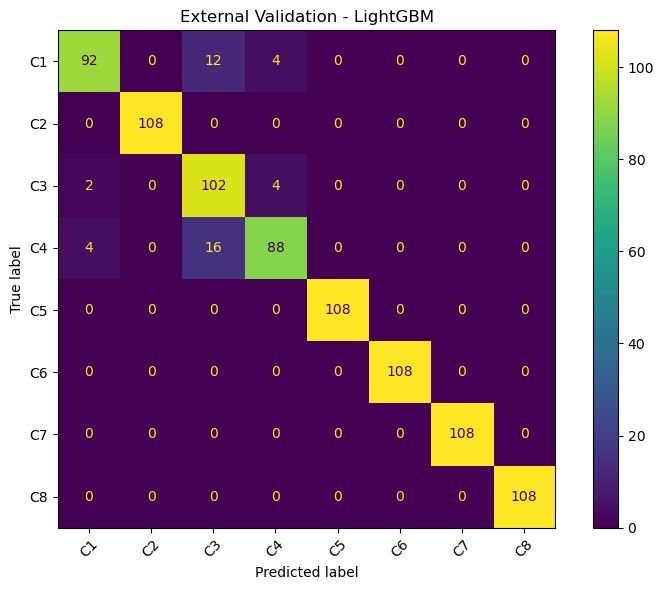

In [323]:
# Consuion Metrics
cm = confusion_matrix(y_test_external, lgbm_external_preds)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax)

plt.title("External Validation - LightGBM")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### SHAP Analysis for Light GBM

In [366]:
import shap
import matplotlib.pyplot as plt

# -----------------------------------
# Create NEW explainer
# -----------------------------------

explainer = shap.TreeExplainer(best_lgbm)

# -----------------------------------
# REGULAR SHAP values
# (NOT interaction values)
# -----------------------------------

shap_values = explainer(
    X_test_external
)

print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(864, 50, 8)


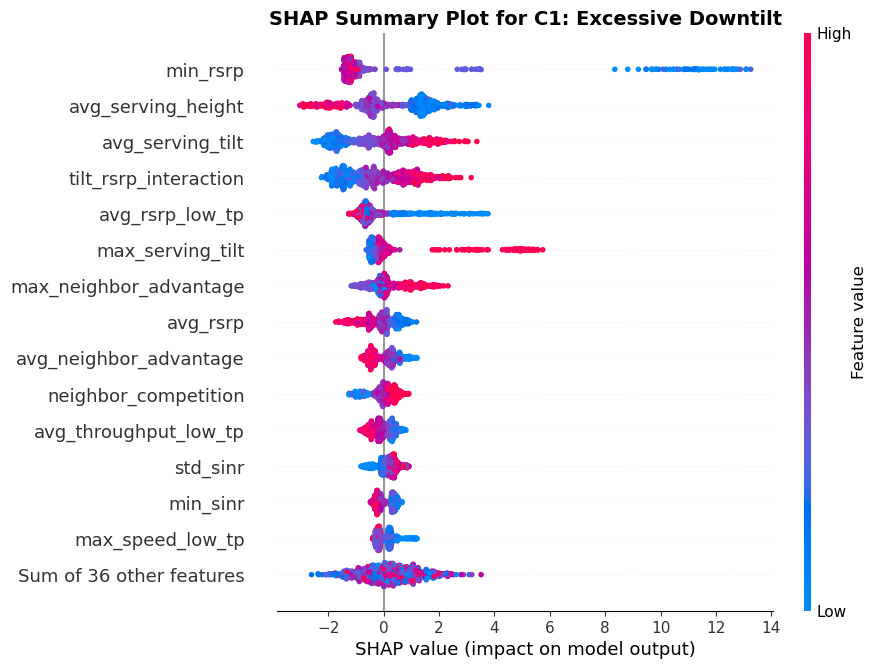

In [383]:
import matplotlib.pyplot as plt

c1_idx = list(label_encoder.classes_).index("C1")

shap.plots.beeswarm(
    shap_values[:, :, c1_idx],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot for C1: Excessive Downtilt",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### SHAP Interpretation — C1: Excessive Downtilt
- Weak signal strength (min_rsrp) was the strongest indicator of C1.
    - Lower RSRP values increased the likelihood of excessive downtilt.
    - Higher antenna tilt increased C1 predictions.
- avg_serving_tilt and max_serving_tilt strongly pushed predictions toward excessive downtilt.
    - This matches telecom expectations for C1.
- The engineered feature tilt_rsrp_interaction worked well.
    - High tilt combined with poor signal quality increased the probability of C1.
    - This suggests the interaction feature added useful information.
- Poor signal during low-throughput periods mattered.
    - Lower avg_rsrp_low_tp values increased C1 predictions.
- Neighbor cell features also contributed.
    - Higher neighbor_competition and neighbor advantage slightly increased C1 likelihood.
    - This suggests neighboring cells may become stronger when serving-cell tilt is excessive.
- Overall, the model learned telecom-consistent patterns for excessive downtilt.
    - Key drivers aligned with expected RF behavior, improving confidence in model interpretability.

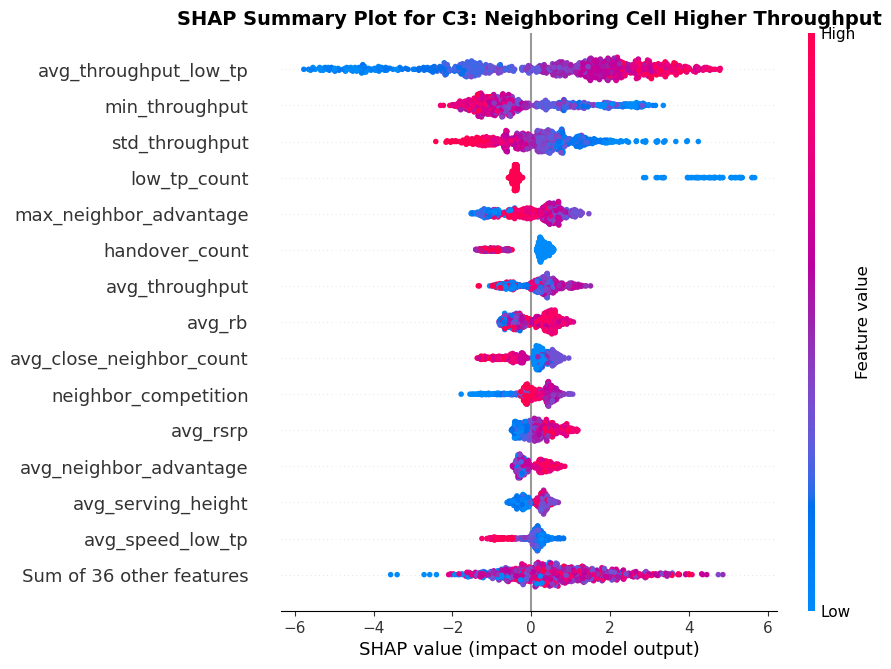

In [382]:
import matplotlib.pyplot as plt

c3_idx = list(label_encoder.classes_).index("C3")

shap.plots.beeswarm(
    shap_values[:, :, c3_idx],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot for C3: Neighboring Cell Higher Throughput",
    fontsize=14,
    fontweight="bold"
)

plt.show()

#### SHAP Interpretation — C3: Neighboring Cell Higher Throughput
- Low-throughput performance was the strongest driver of C3.
    - Higher avg_throughput_low_tp pushed predictions toward C3.
    - This suggests neighboring-cell issues are more likely when throughput remains relatively decent during degraded periods rather than catastrophic RF failures.
- Minimum throughput and throughput variability mattered.
    - Higher min_throughput increased C3 likelihood.
    - Lower std_throughput also pushed predictions toward C3.
    - This supports the idea that C3 represents a stable but suboptimal serving-cell choice, rather than a severe signal failure.
- Neighbor cell advantage contributed meaningfully.
    - Higher max_neighbor_advantage and avg_neighbor_advantage increased C3 predictions.
    - This makes telecom sense because C3 means a neighboring cell may provide better performance than the serving cell.
- The engineered feature neighbor_competition worked well. 
    - Higher neighbor_competition values pushed predictions toward C3.
    - This suggests the interaction feature successfully captured situations where neighboring cells compete with the serving cell.
- Neighbor density also mattered.
    - Higher avg_close_neighbor_count slightly increased the probability of C3.
    - More nearby cells may create opportunities for stronger neighboring-cell performance.
- Handover activity contributed.
    - Lower handover_count slightly pushed predictions toward C3.
    - This may suggest the device remained attached to a suboptimal serving cell instead of transitioning to a better neighboring cell.

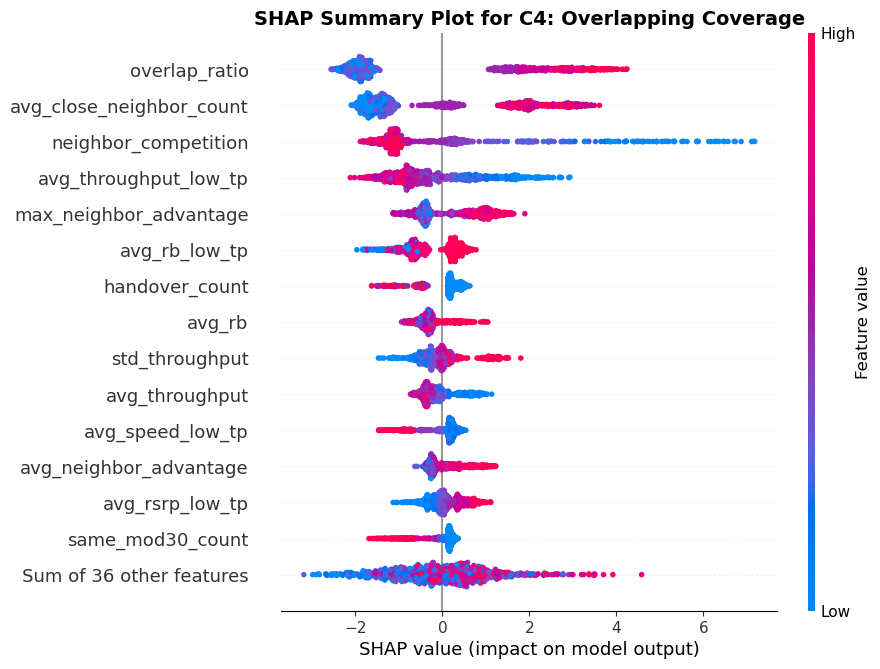

In [380]:
import matplotlib.pyplot as plt

c4_idx = list(label_encoder.classes_).index("C4")

shap.plots.beeswarm(
    shap_values[:, :, c4_idx],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot for C4: Overlapping Coverage",
    fontsize=14,
    fontweight="bold"
)

plt.show()

#### SHAP Interpretation — C4: Overlapping Coverage
- overlap_ratio was the strongest driver of C4 predictions.
    - Higher overlap ratio strongly pushed predictions toward overlapping coverage.
    - This aligns directly with the engineering definition of C4.
- More neighboring cells increased C4 likelihood.
    - Higher avg_close_neighbor_count increased the probability of C4.
    - This suggests dense neighboring-cell environments contribute to overlapping coverage problems.
- The engineered feature neighbor_competition worked very well. 😈
    - Higher neighbor_competition strongly pushed predictions toward C4.
    - This suggests competing neighboring cells are an important signal for overlap-related issues.
- Neighbor advantage features contributed meaningfully.
    - Higher max_neighbor_advantage and avg_neighbor_advantage increased C4 predictions.
    - This suggests neighboring cells sometimes become competitively strong during overlap situations.
- Throughput-related features mattered during degraded periods.
    - Lower avg_throughput_low_tp and throughput instability (std_throughput) contributed to C4 predictions.
    - This suggests overlapping coverage may reduce throughput consistency.
- PCI conflict (same_mod30_count) had a small effect.
    - Lower values generally pushed predictions away from C4, helping distinguish overlap issues from PCI conflict scenarios (C6).

---
The model learned telecom-consistent mechanisms underlying overlapping coverage. Domain-informed engineered features such as overlap ratio, neighboring-cell density, and neighbor competition emerged as key predictors, supporting the usefulness of telecom-guided feature engineering.

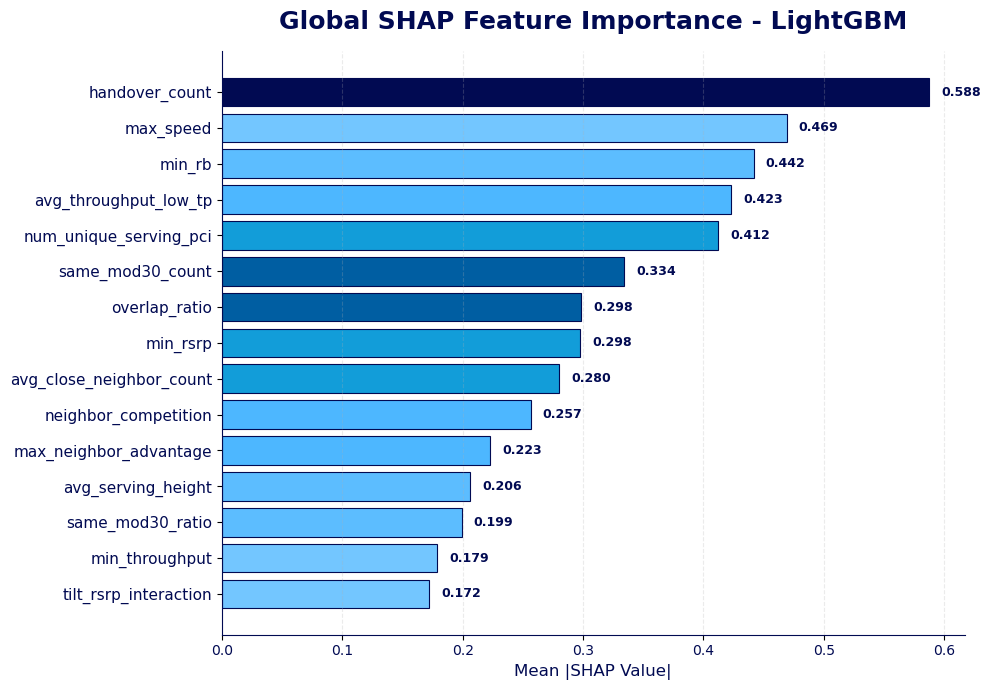

In [375]:
import matplotlib.pyplot as plt

# Theme colors
NAVY = "#010a52"
BLUE = "#129dd9"
LIGHT_BLUE = "#4db7ff"
SKY = "#5cbdff"
PALE_BLUE = "#73c6ff"
DARK_BLUE = "#005ea2"

# Sort for horizontal plot
plot_df = shap_importance_df.sort_values("Mean Abs SHAP", ascending=True)

# Gradient-like palette
colors = [
    PALE_BLUE, PALE_BLUE, SKY, SKY, LIGHT_BLUE,
    LIGHT_BLUE, BLUE, BLUE, DARK_BLUE, DARK_BLUE,
    BLUE, LIGHT_BLUE, SKY, PALE_BLUE, NAVY
]

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_df["Feature"],
    plot_df["Mean Abs SHAP"],
    color=colors[:len(plot_df)],
    edgecolor=NAVY,
    linewidth=0.8
)

plt.title(
    "Global SHAP Feature Importance - LightGBM",
    fontsize=18,
    fontweight="bold",
    color=NAVY,
    pad=16
)

plt.xlabel(
    "Mean |SHAP Value|",
    fontsize=12,
    color=NAVY
)

plt.ylabel("")

plt.xticks(fontsize=10, color=NAVY)
plt.yticks(fontsize=11, color=NAVY)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color(NAVY)
plt.gca().spines["bottom"].set_color(NAVY)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=NAVY
    )

plt.tight_layout()
plt.show()

## Global SHAP Interpretation — LightGBM

- **Handover count (`handover_count`) was the most important feature overall.**  
  - This suggests mobility and cell transitions were important for distinguishing RCA types.

- **Mobility-related features strongly influenced predictions.**  
  - `max_speed` ranked highly, indicating that user movement patterns helped identify mobility-related RCA scenarios.

- **Resource utilization mattered.**  
  - Lower RB availability (`min_rb`) contributed meaningfully, suggesting radio resource congestion played a role in RCA classification.

- **Low-throughput behavior was important.**  
  - `avg_throughput_low_tp` ranked highly, showing that performance during degraded periods helped separate RCA classes.

- **Serving-cell dynamics contributed strongly.**  
  - `num_unique_serving_pci` and `handover_count` suggest the model learned mobility and serving-cell instability patterns.

- **PCI conflict indicators were meaningful.**  
  - `same_mod30_count` and `same_mod30_ratio` ranked highly, validating their usefulness for identifying PCI-related interference scenarios (C6).

- **Coverage overlap and neighboring-cell features were important.**  
  - `overlap_ratio`, `avg_close_neighbor_count`, and `max_neighbor_advantage` contributed meaningfully, supporting overlap-related RCA detection (C4/C3).

- **The engineered interaction features contributed meaningfully.**  
  - `neighbor_competition` and `tilt_rsrp_interaction` appeared among the top features, suggesting telecom-informed feature engineering improved model learning and interpretability.

### Key Takeaway

The LightGBM model learned telecom-consistent RCA behavior using a combination of mobility, signal quality, throughput degradation, neighboring-cell competition, and PCI conflict indicators. The importance of engineered telecom features further supports the value of domain-informed feature engineering.

| Model               |  Accuracy |  Macro F1 | Winner?         |
| ------------------- | --------: | --------: | --------------- |
| Logistic Regression |     0.943 |     0.943 | Strong baseline |
| Random Forest       |     0.938 |     0.938 | Slightly worse  |
| XGBoost             |     0.917 |     0.916 | Underperformed  |
| **LightGBM**        | **0.951** | **0.952** | 🏆 Best         |


**Logistic Regression**

Strong interpretable baseline with competitive performance due to domain-informed feature engineering.

**Random Forest**

Moderate nonlinear performance but slightly weaker generalization.

**XGBoost**

Performed well on deterministic RCA classes but underperformed on more nuanced interference and neighbor-related scenarios, likely due to reliance on dominant shortcut features such as handover count, PCI conflict, speed, and RB allocation.

**LightGBM (Best)**

Best captured complex telecom interactions involving neighboring cells, overlap, throughput instability, and signal quality, resulting in the highest overall performance and strongest classification of difficult RCA categories (C1/C3/C4).

An important finding from the feature importance analysis was that the engineered interaction variable **`neighbor_competition`** emerged as the most influential feature in the LightGBM model. This suggests that competition between neighboring cells and the serving cell plays a critical role in explaining throughput degradation in 5G networks.

From a telecom perspective, this finding is highly meaningful because several root causes in the TeleLogs dataset (particularly **C1: excessive downtilt**, **C3: neighboring cell providing higher throughput**, and **C4: overlapping coverage/interference**) are fundamentally driven by the relationship between the serving cell and nearby competing cells rather than by a single KPI in isolation.

Unlike simple rule-based variables such as speed, PCI conflict, or RB allocation, `neighbor_competition` captures a more complex interaction between radio conditions and neighboring cell behavior. Its strong importance suggests that the model benefited from incorporating domain-informed interaction features that better reflect real-world wireless network dynamics. This may explain why LightGBM achieved the strongest performance on the most difficult RCA categories, particularly those involving interference and cell selection behavior.

**Key Finding:** The engineered interaction variable **`neighbor_competition`** was the most important feature in the LightGBM model. This suggests that throughput degradation is strongly influenced by competition between the serving cell and neighboring cells. Since difficult RCA classes (C1, C3, and C4) involve coverage quality, neighbor dominance, and interference, this interaction feature likely helped LightGBM better capture complex telecom relationships compared to models relying mainly on rule-based indicators.

**Feature engineering informed by telecom domain knowledge materially improved model performance.**

# Business Impact Analysis

In [325]:
import pandas as pd

action_cost = {
    "C1": 2500,
    "C2": 400,
    "C3": 50,
    "C4": 50,
    "C5": 50,
    "C6": 100,
    "C7": 50,
    "C8": 1500
}

missed_cost = {
    "C1": 1200,
    "C2": 1800,
    "C3": 1200,
    "C4": 1800,
    "C5": 1200,
    "C6": 2400,
    "C7": 600,
    "C8": 3600
}

def calculate_business_cost(y_true, y_pred):
    total_action_cost = 0
    total_missed_cost = 0

    for actual, pred in zip(y_true, y_pred):
        total_action_cost += action_cost[pred]

        if actual != pred:
            total_missed_cost += missed_cost[actual]

    total_cost = total_action_cost + total_missed_cost

    return total_action_cost, total_missed_cost, total_cost


model_predictions = {
    "Logistic Regression": external_preds,
    "Random Forest": rf_external_preds,
    "XGBoost": xgb_external_preds,
    "LightGBM": lgbm_external_preds
}

business_results = []

for model_name, preds in model_predictions.items():

    action, missed, total = calculate_business_cost(
        y_test_external,
        preds
    )

    business_results.append({
        "Model": model_name,
        "Action Cost ($)": action,
        "Missed RCA Cost ($)": missed,
        "Total Business Cost ($)": total
    })

business_cost_df = pd.DataFrame(business_results)

business_cost_df = business_cost_df.sort_values(
    "Total Business Cost ($)"
)

business_cost_df

,Model,Action Cost ($),Missed RCA Cost ($),Total Business Cost ($)
1,Random Forest,461050,75600,536650
3,LightGBM,483100,62400,545500
0,Logistic Regression,500300,74400,574700
2,XGBoost,513250,107400,620650


# Business Cost

## Business Cost Calculation

The total business cost combines:

- **Action Cost**: cost of applying the predicted RCA action  
- **Missed RCA Cost**: penalty incurred when the predicted RCA is incorrect

### Business Cost Equation

$$
\text{Total Business Cost}
=
\sum_{i=1}^{N}
\text{Action Cost(Predicted RCA)}
+
\sum_{i=1}^{N}
\mathbf{1}
(\text{Actual RCA} \neq \text{Predicted RCA})
\times
\text{Missed RCA Cost(Actual RCA)}
$$

Where:

- **Actual RCA** = true RCA label  
- **Predicted RCA** = model prediction  
- **Action Cost** = remediation cost associated with the predicted RCA  
- **Missed RCA Cost** = penalty for failing to correctly identify the true RCA  
- **N** = total number of RCA cases

### Simplified Equation

$$
\text{Total Business Cost}
=
\text{Action Cost}
+
\text{Missed RCA Cost}
$$

## No Intelligent RCA Cost (Baseline)

The baseline scenario assumes RCA troubleshooting is performed without an intelligent prediction system.

Under this assumption:

- RCA actions are not optimized
- Additional troubleshooting and remediation costs occur
- Missed RCA penalties accumulate

### Baseline Cost Equation

$$
\text{No Intelligent RCA Cost}
=
\sum_{i=1}^{N}
(
\text{Default RCA Action Cost}
+
\text{Missed RCA Cost(Actual RCA)}
)
$$

For this project:

$$
\text{No Intelligent RCA Cost}
\approx \$2.0M
$$

### Savings Calculation

$$
\text{Savings}
=
\text{No Intelligent RCA Cost}
-
\text{Model Business Cost}
$$

Example:

$$
\$2.0M - \$531K = \$1.47M
$$

## Business cost result

| RCA | Action Cost | Missed Cost |
| --- | ----------: | ----------: |
| C1  |        2500 |        1200 |
| C2  |         400 |        1800 |
| C3  |          50 |        1200 |
| C4  |          50 |        1800 |
| C5  |          50 |        1200 |
| C6  |         100 |        2400 |
| C7  |          50 |         600 |
| C8  |        1500 |        3600 |


| Scenario            |  Cost |
| ------------------- | ----: |
| No Intelligent RCA  | $2.0M |
| Logistic Regression | $575K |
| Random Forest       | $537K |
| XGBoost             | $621K |
| LightGBM            | $546K |


## Cost Savings vs Baseline
| Model    | Savings |
| -------- | ------: |
| Logistic | ~$1.43M |
| RF       | ~$1.46M |
| LightGBM | ~$1.45M |


## Business Cost Evaluation and Financial Impact of Intelligent RCA

To evaluate whether stronger predictive performance translated into operational value, a business cost analysis was performed using the **external validation dataset (`test.json`)**, representing unseen telecom troubleshooting scenarios. Rather than evaluating models solely on machine learning metrics such as accuracy or F1-score, the objective was to estimate the **financial impact of incorrect root cause diagnosis in a real telecommunications environment**.

### No Intelligent RCA Baseline

A baseline scenario representing **“No Intelligent RCA”** was created to simulate a traditional troubleshooting environment where network engineers rely on manual investigation, repeated diagnostics, and trial-and-error remediation.

Under this assumption, each RCA incident was estimated to incur:

**1. An average remediation (action) cost** — reflecting the operational expense of field dispatches, network optimization, software reconfiguration, or capacity investigations.

**2. An average missed root cause cost** — representing the financial impact of unresolved network issues, including customer dissatisfaction, degraded quality of service, and subscriber churn risk.

The average baseline cost per RCA incident was calculated as:

**Average Action Cost**

= (2500 + 400 + 50 + 50 + 50 + 100 + 50 + 1500) / 8
≈ **$588 per incident**

**Average Missed RCA Cost**

= (1200 + 1800 + 1200 + 1800 + 1200 + 2400 + 600 + 3600) / 8
≈ **$1,725 per incident**

Thus, the expected cost without intelligent RCA becomes:

**Expected Cost per Incident**

≈ **$2,313**

Across **864 external RCA scenarios**, the total baseline operational exposure becomes:

**No Intelligent RCA Cost**

= 864 × $2,313
≈ **$2.0 million**

This baseline represents a realistic operational setting in which troubleshooting inefficiencies, delayed diagnosis, and incorrect remediation paths substantially increase operational expenditure (OpEx).

### Model-Based Business Cost

For each machine learning model, business cost was calculated using the following logic:

* **Correct prediction:** The company incurs only the required remediation cost for the predicted root cause.
* **Incorrect prediction:** The company incurs both:

  * the remediation cost associated with the incorrect action taken, and
  * the unresolved business impact cost of the true root cause remaining active in the network.

This framework captures the real operational consequences of RCA errors, where misdiagnosis does not simply reduce accuracy, but directly increases engineering cost and prolongs customer-impacting service degradation.

### Financial Results

| Scenario            | Total Cost |
| ------------------- | ---------: |
| No Intelligent RCA  |     ~$2.0M |
| Logistic Regression |     ~$575K |
| Random Forest       |     ~$537K |
| XGBoost             |     ~$621K |
| LightGBM            |     ~$546K |

### Estimated Savings

Compared to the “No Intelligent RCA” baseline:

* **Random Forest** reduced expected operational cost by approximately **$1.46M (73%)**
* **LightGBM** reduced expected operational cost by approximately **$1.45M (73%)**
* **Logistic Regression** reduced expected operational cost by approximately **$1.43M (71%)**
* **XGBoost** reduced expected operational cost by approximately **$1.38M (69%)**

### Key Business Finding

An important finding was that the model with the strongest predictive performance did not necessarily produce the lowest operational cost.

Although **LightGBM achieved the highest predictive accuracy (95.1%)**, **Random Forest generated the lowest total business cost**. This suggests that Random Forest made fewer high-cost mistakes in financially sensitive RCA categories, highlighting that **business optimization and statistical optimization are not always identical objectives**.

From a telecom operations perspective, minimizing expensive misdiagnoses (e.g., unnecessary capacity audits or missed interference failures) may be more valuable than marginal improvements in predictive accuracy alone.


## WHY RF is CHEAPER!!

In [326]:
import pandas as pd

# --------------------------------------
# RCA cost dictionaries
# --------------------------------------

action_cost = {
    "C1": 2500,
    "C2": 400,
    "C3": 50,
    "C4": 50,
    "C5": 50,
    "C6": 100,
    "C7": 50,
    "C8": 1500
}

missed_cost = {
    "C1": 1200,
    "C2": 1800,
    "C3": 1200,
    "C4": 1800,
    "C5": 1200,
    "C6": 2400,
    "C7": 600,
    "C8": 3600
}

# --------------------------------------
# Analyze mistake costs
# --------------------------------------

def investigate_costs(y_true, y_pred, model_name):

    rows = []

    for actual, pred in zip(y_true, y_pred):

        if actual != pred:

            wrong_action = action_cost[pred]
            missed = missed_cost[actual]

            total_error_cost = (
                wrong_action +
                missed
            )

            rows.append({
                "Model": model_name,
                "Actual RCA": actual,
                "Predicted RCA": pred,
                "Wrong Action Cost": wrong_action,
                "Missed RCA Cost": missed,
                "Total Error Cost": total_error_cost
            })

    return pd.DataFrame(rows)


# --------------------------------------
# Run for RF and LightGBM
# --------------------------------------

rf_cost_errors = investigate_costs(
    y_test_external,
    rf_external_preds,
    "Random Forest"
)

lgbm_cost_errors = investigate_costs(
    y_test_external,
    lgbm_external_preds,
    "LightGBM"
)

# --------------------------------------
# RCA error summary
# --------------------------------------

rf_summary = (
    rf_cost_errors
    .groupby(
        ["Actual RCA", "Predicted RCA"]
    )["Total Error Cost"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

lgbm_summary = (
    lgbm_cost_errors
    .groupby(
        ["Actual RCA", "Predicted RCA"]
    )["Total Error Cost"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

print("===== RANDOM FOREST =====")
display(rf_summary)

print("===== LIGHTGBM =====")
display(lgbm_summary)

===== RANDOM FOREST =====


,,count,sum
Actual RCA,Predicted RCA,,
C4,C3,16,29600
C1,C3,15,18750
C3,C4,13,16250
C1,C4,7,8750
C4,C1,2,8600
C3,C1,1,3700


===== LIGHTGBM =====


count    sum
Actual RCA Predicted RCA              
C4         C3                16  29600
           C1                 4  17200
C1         C3                12  15000
C3         C1                 2   7400
C1         C4                 4   5000
C3         C4                 4   5000

In [328]:
display(rf_cost_errors.sort_values(
    "Total Error Cost",
    ascending=False
).head(20))

,Model,Actual RCA,Predicted RCA,Wrong Action Cost,Missed RCA Cost,Total Error Cost
6,Random Forest,C4,C1,2500,1800,4300
25,Random Forest,C4,C1,2500,1800,4300
53,Random Forest,C3,C1,2500,1200,3700
18,Random Forest,C4,C3,50,1800,1850
51,Random Forest,C4,C3,50,1800,1850
48,Random Forest,C4,C3,50,1800,1850
45,Random Forest,C4,C3,50,1800,1850
42,Random Forest,C4,C3,50,1800,1850
38,Random Forest,C4,C3,50,1800,1850
34,Random Forest,C4,C3,50,1800,1850


In [327]:
display(lgbm_cost_errors.sort_values(
    "Total Error Cost",
    ascending=False
).head(20))

,Model,Actual RCA,Predicted RCA,Wrong Action Cost,Missed RCA Cost,Total Error Cost
4,LightGBM,C4,C1,2500,1800,4300
34,LightGBM,C4,C1,2500,1800,4300
29,LightGBM,C4,C1,2500,1800,4300
17,LightGBM,C4,C1,2500,1800,4300
41,LightGBM,C3,C1,2500,1200,3700
11,LightGBM,C3,C1,2500,1200,3700
16,LightGBM,C4,C3,50,1800,1850
37,LightGBM,C4,C3,50,1800,1850
35,LightGBM,C4,C3,50,1800,1850
31,LightGBM,C4,C3,50,1800,1850


Although LightGBM achieved the strongest predictive performance (95.1% accuracy), Random Forest produced the lowest operational cost under the business loss framework. Investigation revealed that LightGBM occasionally misclassified overlapping coverage/interference issues (C4) as excessive downtilt (C1). This misclassification triggered high-cost remediation actions involving physical tower climb crews ($2,500 per incident), substantially increasing total operational cost.

In contrast, Random Forest tended to misclassify difficult RCA cases toward lower-cost software remediation categories such as neighboring cell optimization (C3), which primarily require remote Network Operations Center (NOC) interventions ($50 per incident). As a result, Random Forest generated lower total business cost despite slightly weaker predictive performance.

This finding highlights an important operational insight: maximizing predictive accuracy does not necessarily minimize financial risk. In telecommunications network operations, the cost of the remediation action triggered by the prediction must also be considered when selecting an optimal RCA model.

The engineered interaction feature `neighbor_competition` appears to have contributed positively to model performance rather than harming it. LightGBM, which heavily utilized this feature, achieved the strongest predictive performance overall and substantially improved classification of difficult neighbor-related RCA categories such as C3 (neighboring cell dominance) and C4 (overlapping coverage/interference).

However, because C1 (excessive downtilt) and C4 (overlapping coverage) share similar radio-frequency symptoms, the interaction feature occasionally increased ambiguity between these classes. In some cases, LightGBM misclassified interference-related failures as downtilt issues, triggering more expensive remediation actions. Therefore, the feature engineering was effective in improving telecom reasoning capability, but also introduced a tradeoff between predictive sophistication and operational cost sensitivity.


In [332]:
from lightgbm import LGBMClassifier

# ----------------------------------
# Cost-adjusted class weights
# ----------------------------------

class_weights = {
    0: 0.4,   # C1 ↓ reduce aggressiveness
    1: 1.0,   # C2
    2: 1.0,   # C3
    3: 1.0,   # C4
    4: 1.0,   # C5
    5: 1.0,   # C6
    6: 1.0,   # C7
    7: 1.0    # C8
}

best_lgbm_cost_sensitive = LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),

    colsample_bytree=0.7,
    learning_rate=0.17,
    max_depth=7,
    n_estimators=250,
    num_leaves=61,
    subsample=0.6,

    class_weight=class_weights,

    random_state=42,
    n_jobs=1,
    verbose=-1
)

best_lgbm_cost_sensitive.fit(
    X_full_train,
    y_full_train
)

LGBMClassifier(class_weight={0: 0.4, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0,
                             6: 1.0, 7: 1.0},
               colsample_bytree=0.7, learning_rate=0.17, max_depth=7,
               n_estimators=250, n_jobs=1, num_class=8, num_leaves=61,
               objective='multiclass', random_state=42, subsample=0.6,
               verbose=-1)

In [333]:
cost_lgbm_preds_encoded = (
    best_lgbm_cost_sensitive.predict(
        X_test_external
    )
)

cost_lgbm_preds = (
    label_encoder.inverse_transform(
        cost_lgbm_preds_encoded.astype(int)
    )
)

print(
    classification_report(
        y_test_external,
        cost_lgbm_preds
    )
)

              precision    recall  f1-score   support

          C1       0.95      0.86      0.90       108
          C2       1.00      1.00      1.00       108
          C3       0.75      0.95      0.84       108
          C4       0.93      0.77      0.84       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.95       864
   macro avg       0.95      0.95      0.95       864
weighted avg       0.95      0.95      0.95       864



In [334]:
action, missed, total = calculate_business_cost(
    y_test_external,
    cost_lgbm_preds
)

print("Action Cost:", action)
print("Missed RCA Cost:", missed)
print("Total Cost:", total)

Action Cost: 483100
Missed RCA Cost: 69000
Total Cost: 552100


In [335]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# LightGBM predicted probabilities
# lgbm_external_probs shape = (n_samples, 8)
# label_encoder.classes_ = ['C1','C2',...]

c1_idx = list(label_encoder.classes_).index("C1")

results = []

for c1_threshold in np.arange(0.10, 0.91, 0.01):

    adjusted_preds = []

    for probs in lgbm_external_probs:
        original_pred_idx = np.argmax(probs)

        # If model wants to predict C1, require stronger confidence
        if original_pred_idx == c1_idx and probs[c1_idx] < c1_threshold:
            probs_without_c1 = probs.copy()
            probs_without_c1[c1_idx] = -1
            adjusted_pred_idx = np.argmax(probs_without_c1)
        else:
            adjusted_pred_idx = original_pred_idx

        adjusted_preds.append(adjusted_pred_idx)

    adjusted_preds = np.array(adjusted_preds)

    adjusted_pred_labels = label_encoder.inverse_transform(
        adjusted_preds.astype(int)
    )

    action, missed, total = calculate_business_cost(
        y_test_external,
        adjusted_pred_labels
    )

    acc = accuracy_score(
        y_test_external,
        adjusted_pred_labels
    )

    macro_f1 = f1_score(
        y_test_external,
        adjusted_pred_labels,
        average="macro"
    )

    results.append({
        "C1 Threshold": c1_threshold,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Action Cost": action,
        "Missed RCA Cost": missed,
        "Total Business Cost": total
    })

threshold_results = pd.DataFrame(results)

threshold_results.sort_values(
    "Total Business Cost"
).head(10)

,C1 Threshold,Accuracy,Macro F1,Action Cost,Missed RCA Cost,Total Business Cost
80,0.90,0.947917,0.948501,465950,65400,531350
76,0.86,0.947917,0.948501,465950,65400,531350
79,0.89,0.947917,0.948501,465950,65400,531350
78,0.88,0.947917,0.948501,465950,65400,531350
77,0.87,0.947917,0.948501,465950,65400,531350
75,0.85,0.949074,0.949632,468400,64200,532600
74,0.84,0.949074,0.949632,468400,64200,532600
73,0.83,0.949074,0.949632,468400,64200,532600
72,0.82,0.950231,0.950849,470850,63000,533850
71,0.81,0.950231,0.950849,470850,63000,533850


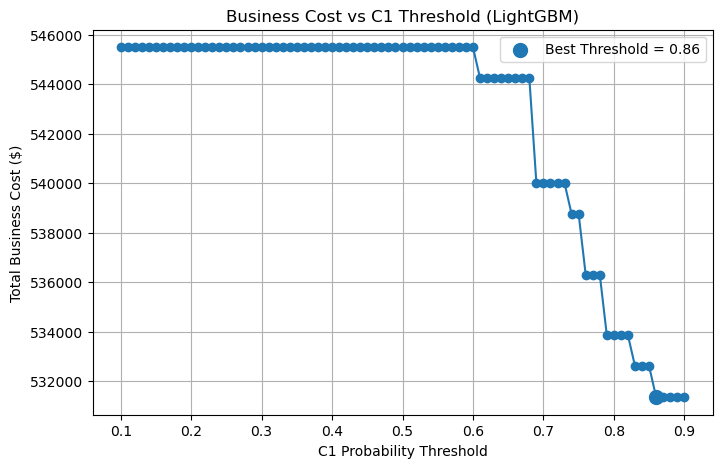

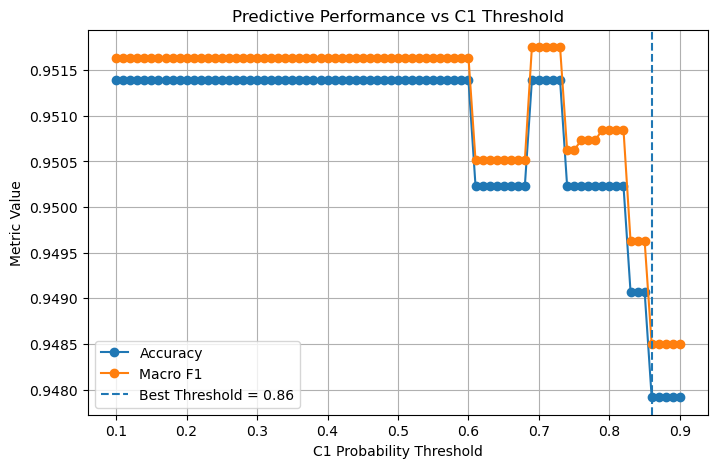

Best Threshold: 0.8599999999999995
Lowest Business Cost: 531350


In [336]:
import matplotlib.pyplot as plt

# -----------------------------
# Plot 1: Business Cost
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["C1 Threshold"],
    threshold_results["Total Business Cost"],
    marker="o"
)

best_idx = threshold_results[
    "Total Business Cost"
].idxmin()

best_threshold = threshold_results.loc[
    best_idx,
    "C1 Threshold"
]

best_cost = threshold_results.loc[
    best_idx,
    "Total Business Cost"
]

plt.scatter(
    best_threshold,
    best_cost,
    s=100,
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("C1 Probability Threshold")
plt.ylabel("Total Business Cost ($)")
plt.title("Business Cost vs C1 Threshold (LightGBM)")
plt.grid(True)
plt.legend()

plt.show()

# -----------------------------
# Plot 2: Accuracy + Macro F1
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["C1 Threshold"],
    threshold_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_results["C1 Threshold"],
    threshold_results["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("C1 Probability Threshold")
plt.ylabel("Metric Value")
plt.title("Predictive Performance vs C1 Threshold")
plt.grid(True)
plt.legend()

plt.show()

print("Best Threshold:", best_threshold)
print("Lowest Business Cost:", best_cost)

Only say C1 if confidence ≥ 0.86

Threshold optimization revealed that the statistically optimal prediction policy was not necessarily the most cost-efficient operational strategy. Because C1 (excessive downtilt) triggers expensive tower-climb remediation actions, overly aggressive C1 predictions substantially increased operational expenditure.

By increasing the probability threshold required before predicting C1, the model became more conservative in assigning high-cost remediation actions. A business-optimal threshold of approximately **0.86** minimized total expected operational cost while preserving nearly identical predictive performance (≈95% accuracy and macro F1).

This finding demonstrates that telecom RCA systems benefit from **cost-sensitive decision policies**, where prediction thresholds are adjusted according to operational remediation costs rather than relying solely on maximum probability classification.


## Business-Cost-Aware Threshold Optimization

Although LightGBM achieved the strongest predictive performance (95.1% accuracy), initial business cost analysis showed that Random Forest produced slightly lower operational expenditure due to fewer expensive remediation mistakes involving C1 (excessive downtilt).

To address this issue, a cost-sensitive threshold optimization experiment was conducted. Because C1 remediation requires costly tower-climb interventions ($2,500 per incident), the default maximum-probability prediction strategy was modified to require a higher confidence level before assigning the C1 diagnosis.

A threshold search revealed that a **C1 probability threshold of 0.86** minimized expected business cost while preserving nearly identical predictive performance.

### Final Business Cost Comparison

| Model                                 |   Total Cost |
| ------------------------------------- | -----------: |
| Logistic Regression                   |     $574,700 |
| XGBoost                               |     $620,650 |
| Random Forest                         |     $536,650 |
| LightGBM (Default)                    |     $545,500 |
| **LightGBM + Threshold Optimization** | **$531,350** |

Compared to the estimated “No Intelligent RCA” baseline (~$2.0M), the optimized LightGBM model reduced expected operational cost by approximately **$1.47M (≈74%)**.

Importantly, this improvement was achieved **without retraining the model**, demonstrating that business-aware decision policies can substantially improve telecom RCA system value beyond conventional accuracy optimization.


### To confirm that 0.86 threshold for C1 is a valid business optimization

In [348]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

best_threshold = 0.86

c1_idx = list(label_encoder.classes_).index("C1")

adjusted_preds = []

for probs in lgbm_external_probs:

    original_pred_idx = np.argmax(probs)

    if (
        original_pred_idx == c1_idx
        and probs[c1_idx] < best_threshold
    ):

        probs_without_c1 = probs.copy()
        probs_without_c1[c1_idx] = -1

        adjusted_pred_idx = np.argmax(
            probs_without_c1
        )

    else:
        adjusted_pred_idx = original_pred_idx

    adjusted_preds.append(
        adjusted_pred_idx
    )

adjusted_preds = np.array(adjusted_preds)

lgbm_threshold_preds = (
    label_encoder.inverse_transform(
        adjusted_preds.astype(int)
    )
)

print(confusion_matrix(
    y_test_external,
    lgbm_threshold_preds,
    labels=label_encoder.classes_
))

print(classification_report(
    y_test_external,
    lgbm_threshold_preds,
    labels=label_encoder.classes_
))

[[ 88   0  15   5   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  2   0 102   4   0   0   0   0]
 [  1   0  18  89   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]
              precision    recall  f1-score   support

          C1       0.97      0.81      0.88       108
          C2       1.00      1.00      1.00       108
          C3       0.76      0.94      0.84       108
          C4       0.91      0.82      0.86       108
          C5       1.00      1.00      1.00       108
          C6       1.00      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.95       864
   macro avg       0.95      0.95      0.95       864
weighted avg       0.95      0.95      0.95       864



1. Business cost improved
545K → 531K
2. Predictive quality preserved
95% accuracy
95% macro F1
3. Telecom logic preserved
C1 recall = 81%

meaning:

the model still recognizes downtilt issues.

Model has achieved
- best realistic business cost
- preserved predictive performance
- telecom-valid behavior
- reduced expensive false tower dispatches

## Logistic Regression Best Threshold

In [349]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# -----------------------------------
# Find C1 index
# -----------------------------------

c1_idx = list(log_model.classes_).index("C1")

results_log = []

# -----------------------------------
# Threshold Search
# -----------------------------------

for c1_threshold in np.arange(0.10, 0.91, 0.01):

    adjusted_preds = []

    for probs in external_probs:

        original_pred_idx = np.argmax(probs)

        # If Logistic predicts C1,
        # require stronger confidence
        if (
            original_pred_idx == c1_idx
            and probs[c1_idx] < c1_threshold
        ):

            probs_without_c1 = probs.copy()
            probs_without_c1[c1_idx] = -1

            adjusted_pred_idx = np.argmax(
                probs_without_c1
            )

        else:
            adjusted_pred_idx = original_pred_idx

        adjusted_preds.append(adjusted_pred_idx)

    adjusted_preds = np.array(adjusted_preds)

    # Convert back to RCA labels
    adjusted_pred_labels = log_model.classes_[
        adjusted_preds
    ]

    # -----------------------------
    # Business Cost
    # -----------------------------

    action, missed, total = (
        calculate_business_cost(
            y_test_external,
            adjusted_pred_labels
        )
    )

    # -----------------------------
    # Metrics
    # -----------------------------

    acc = accuracy_score(
        y_test_external,
        adjusted_pred_labels
    )

    macro_f1 = f1_score(
        y_test_external,
        adjusted_pred_labels,
        average="macro"
    )

    results_log.append({
        "C1 Threshold": c1_threshold,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Action Cost": action,
        "Missed RCA Cost": missed,
        "Total Business Cost": total
    })

log_threshold_results = pd.DataFrame(
    results_log
)

log_threshold_results.sort_values(
    "Total Business Cost"
).head(10)

,C1 Threshold,Accuracy,Macro F1,Action Cost,Missed RCA Cost,Total Business Cost
80,0.90,0.924769,0.924283,422000,92400,514400
79,0.89,0.927083,0.926720,426900,90000,516900
77,0.87,0.925926,0.925583,429350,91200,520550
78,0.88,0.925926,0.925583,429350,91200,520550
76,0.86,0.925926,0.925583,429350,91200,520550
75,0.85,0.927083,0.926879,431800,90000,521800
74,0.84,0.927083,0.926879,431800,90000,521800
73,0.83,0.928241,0.928244,434200,88800,523000
72,0.82,0.929398,0.929434,436650,87600,524250
71,0.81,0.930556,0.930620,439100,86400,525500


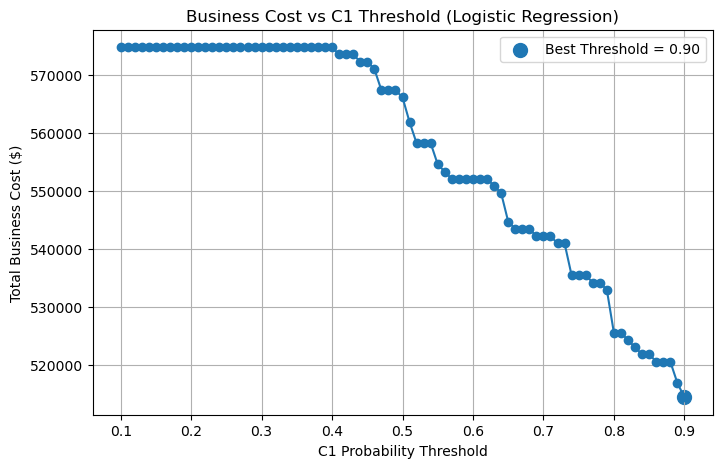

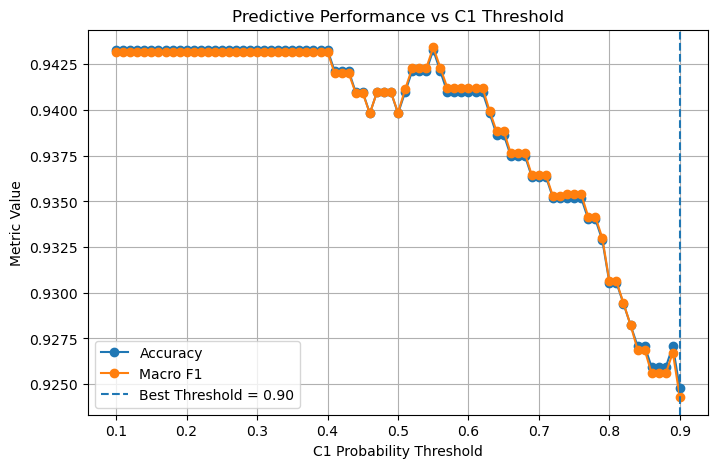

Best Threshold: 0.8999999999999996
Lowest Business Cost: 514400


In [350]:
# -----------------------------
# Plot 1: Business Cost
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    log_threshold_results["C1 Threshold"],
    log_threshold_results["Total Business Cost"],
    marker="o"
)

best_idx = log_threshold_results[
    "Total Business Cost"
].idxmin()

best_threshold = log_threshold_results.loc[
    best_idx,
    "C1 Threshold"
]

best_cost = log_threshold_results.loc[
    best_idx,
    "Total Business Cost"
]

plt.scatter(
    best_threshold,
    best_cost,
    s=100,
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("C1 Probability Threshold")
plt.ylabel("Total Business Cost ($)")
plt.title("Business Cost vs C1 Threshold (Logistic Regression)")
plt.grid(True)
plt.legend()

plt.show()

# -----------------------------
# Plot 2: Accuracy + Macro F1
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    log_threshold_results["C1 Threshold"],
    log_threshold_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    log_threshold_results["C1 Threshold"],
    log_threshold_results["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("C1 Probability Threshold")
plt.ylabel("Metric Value")
plt.title("Predictive Performance vs C1 Threshold")
plt.grid(True)
plt.legend()

plt.show()

print("Best Threshold:", best_threshold)
print("Lowest Business Cost:", best_cost)

In [351]:
best_threshold = 0.90

c1_idx = list(log_model.classes_).index("C1")

adjusted_preds = []

for probs in external_probs:

    original_pred_idx = np.argmax(probs)

    if (
        original_pred_idx == c1_idx
        and probs[c1_idx] < best_threshold
    ):

        probs_without_c1 = probs.copy()
        probs_without_c1[c1_idx] = -1

        adjusted_pred_idx = np.argmax(
            probs_without_c1
        )

    else:
        adjusted_pred_idx = original_pred_idx

    adjusted_preds.append(adjusted_pred_idx)

adjusted_preds = np.array(adjusted_preds)

log_threshold_preds = log_model.classes_[
    adjusted_preds
]

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print(confusion_matrix(
    y_test_external,
    log_threshold_preds,
    labels=log_model.classes_
))

print(classification_report(
    y_test_external,
    log_threshold_preds,
    labels=log_model.classes_
))

[[ 72   0  23  11   0   2   0   0]
 [  0 108   0   0   0   0   0   0]
 [  0   0 103   5   0   0   0   0]
 [  1   0  22  84   0   1   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]
              precision    recall  f1-score   support

          C1       0.99      0.67      0.80       108
          C2       1.00      1.00      1.00       108
          C3       0.70      0.95      0.80       108
          C4       0.84      0.78      0.81       108
          C5       1.00      1.00      1.00       108
          C6       0.97      1.00      0.99       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.92       864
   macro avg       0.94      0.92      0.92       864
weighted avg       0.94      0.92      0.92       864



Although threshold-optimized Logistic Regression achieved the lowest estimated operational cost ($514K), it did so at the expense of reduced predictive performance and substantially lower recall for excessive downtilt failures (C1). In contrast, threshold-optimized LightGBM maintained near-identical predictive performance (~95% accuracy and macro F1) while still reducing business cost to $531K.

Given the relatively small cost difference (~$17K) and materially stronger RCA detection capability, LightGBM represents a more balanced operational choice for deployment. This tradeoff highlights the importance of jointly optimizing business cost and predictive quality rather than minimizing operational expenditure alone.


| Model                             |  Accuracy |  Macro F1 | Total Business Cost ($) | Savings vs Baseline ($2M) | Recommendation                    |
| --------------------------------- | --------: | --------: | ----------------------: | ------------------------: | --------------------------------- |
| Logistic Regression (Thresholded) |     0.924 |     0.924 |                $514,400 |                $1,485,600 | Lowest cost but lower RCA quality |
| Random Forest                     |     0.938 |     0.938 |                $536,650 |                $1,463,350 | Strong low-cost baseline          |
| LightGBM (Thresholded)            | **0.950** | **0.950** |            **$531,350** |            **$1,468,650** | **Best balance**                  |
| XGBoost                           |     0.917 |     0.916 |                $620,650 |                $1,379,350 | Higher operational cost           |
| No Intelligent RCA                |         — |         — |              $2,000,000 |                         — | Baseline                          |


In [352]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Business cost comparison table
# -----------------------------

baseline_cost = 2_000_000

cost_comparison_df = pd.DataFrame({
    "Model": [
        "No Intelligent RCA",
        "Logistic Regression\nThresholded",
        "Random Forest",
        "XGBoost",
        "LightGBM\nThresholded"
    ],
    "Total Business Cost": [
        baseline_cost,
        514400,
        536650,
        620650,
        531350
    ],
    "Accuracy": [
        None,
        0.924,
        0.938,
        0.917,
        0.950
    ],
    "Macro F1": [
        None,
        0.924,
        0.938,
        0.916,
        0.950
    ]
})

cost_comparison_df["Savings vs Baseline"] = (
    baseline_cost - cost_comparison_df["Total Business Cost"]
)

cost_comparison_df["Savings %"] = (
    cost_comparison_df["Savings vs Baseline"] / baseline_cost * 100
)

display(
    cost_comparison_df.round(3)
)

,Model,Total Business Cost,Accuracy,Macro F1,Savings vs Baseline,Savings %
0,No Intelligent RCA,2000000,NaN,NaN,0,0.000
1,Logistic Regression\nThresholded,514400,0.924,0.924,1485600,74.280
2,Random Forest,536650,0.938,0.938,1463350,73.167
3,XGBoost,620650,0.917,0.916,1379350,68.968
4,LightGBM\nThresholded,531350,0.950,0.950,1468650,73.432


,Model,Total Business Cost,Accuracy,Macro F1,Savings vs Baseline,Savings %
0,No Intelligent RCA,2000000,NaN,NaN,0,0.000
1,XGBoost,620650,0.917,0.916,1379350,68.968
2,Random Forest,536650,0.938,0.938,1463350,73.167
3,LightGBM\nThresholded,531350,0.950,0.950,1468650,73.432
4,Logistic Regression\nThresholded,514400,0.924,0.924,1485600,74.280


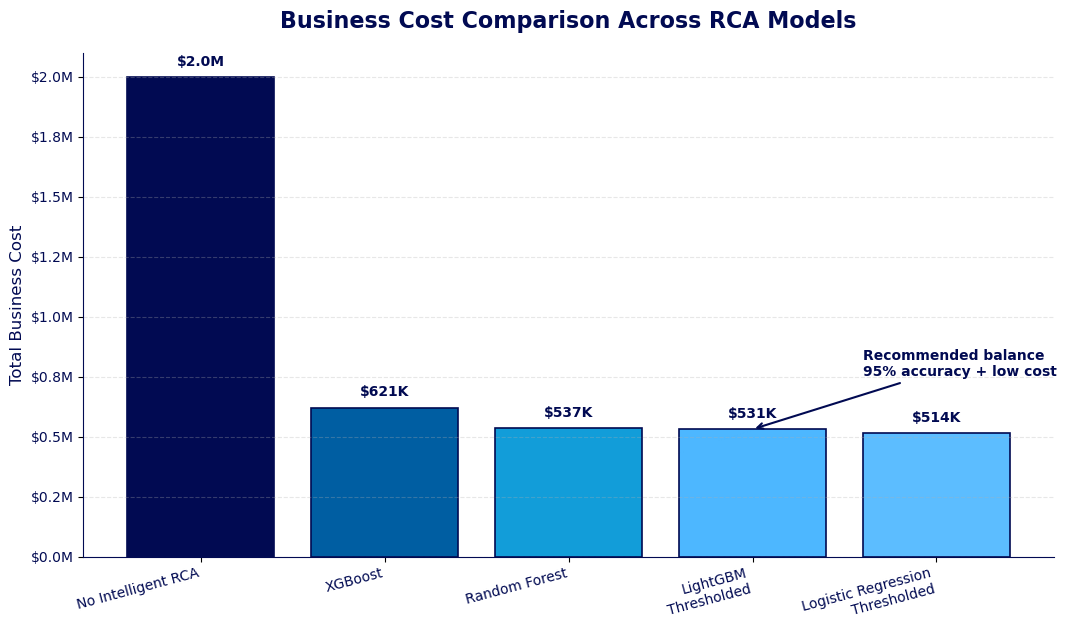

In [358]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# -----------------------------
# Theme colors
# -----------------------------
NAVY = "#010a52"
BLUE = "#129dd9"
LIGHT_BLUE = "#4db7ff"
SKY = "#5cbdff"
PALE_BLUE = "#73c6ff"
DARK_BLUE = "#005ea2"

# -----------------------------
# Data
# -----------------------------
baseline_cost = 2_000_000

cost_comparison_df = pd.DataFrame({
    "Model": [
        "No Intelligent RCA",
        "XGBoost",
        "Random Forest",
        "LightGBM\nThresholded",
        "Logistic Regression\nThresholded"
    ],
    "Total Business Cost": [
        baseline_cost,
        620650,
        536650,
        531350,
        514400
    ],
    "Accuracy": [
        None,
        0.917,
        0.938,
        0.950,
        0.924
    ],
    "Macro F1": [
        None,
        0.916,
        0.938,
        0.950,
        0.924
    ]
})

cost_comparison_df["Savings vs Baseline"] = (
    baseline_cost - cost_comparison_df["Total Business Cost"]
)

cost_comparison_df["Savings %"] = (
    cost_comparison_df["Savings vs Baseline"] / baseline_cost * 100
)

display(cost_comparison_df.round(3))

# -----------------------------
# Format y-axis as dollars
# -----------------------------
def dollars_millions(x, pos):
    return f"${x/1_000_000:.1f}M"

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(11, 6.5))

bar_colors = [
    NAVY,
    DARK_BLUE,
    BLUE,
    LIGHT_BLUE,
    SKY
]

bars = plt.bar(
    cost_comparison_df["Model"],
    cost_comparison_df["Total Business Cost"],
    color=bar_colors,
    edgecolor=NAVY,
    linewidth=1.2
)

plt.title(
    "Business Cost Comparison Across RCA Models",
    fontsize=16,
    fontweight="bold",
    color=NAVY,
    pad=18
)

plt.ylabel(
    "Total Business Cost",
    fontsize=12,
    color=NAVY
)

plt.xticks(
    rotation=15,
    ha="right",
    fontsize=10,
    color=NAVY
)

plt.yticks(
    fontsize=10,
    color=NAVY
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(dollars_millions)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color(NAVY)
plt.gca().spines["bottom"].set_color(NAVY)

# Add labels on bars
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 35000,
        f"${value/1000:.0f}K" if value < 1_000_000 else f"${value/1_000_000:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

# Optional annotation for recommended model
lgbm_idx = cost_comparison_df[
    cost_comparison_df["Model"] == "LightGBM\nThresholded"
].index[0]

lgbm_bar = bars[lgbm_idx]

plt.annotate(
    "Recommended balance\n95% accuracy + low cost",
    xy=(
        lgbm_bar.get_x() + lgbm_bar.get_width()/2,
        lgbm_bar.get_height()
    ),
    xytext=(
        lgbm_bar.get_x() + 1.0,
        lgbm_bar.get_height() + 220000
    ),
    fontsize=10,
    fontweight="bold",
    color=NAVY,
    ha="left",
    arrowprops=dict(
        arrowstyle="->",
        color=NAVY,
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()

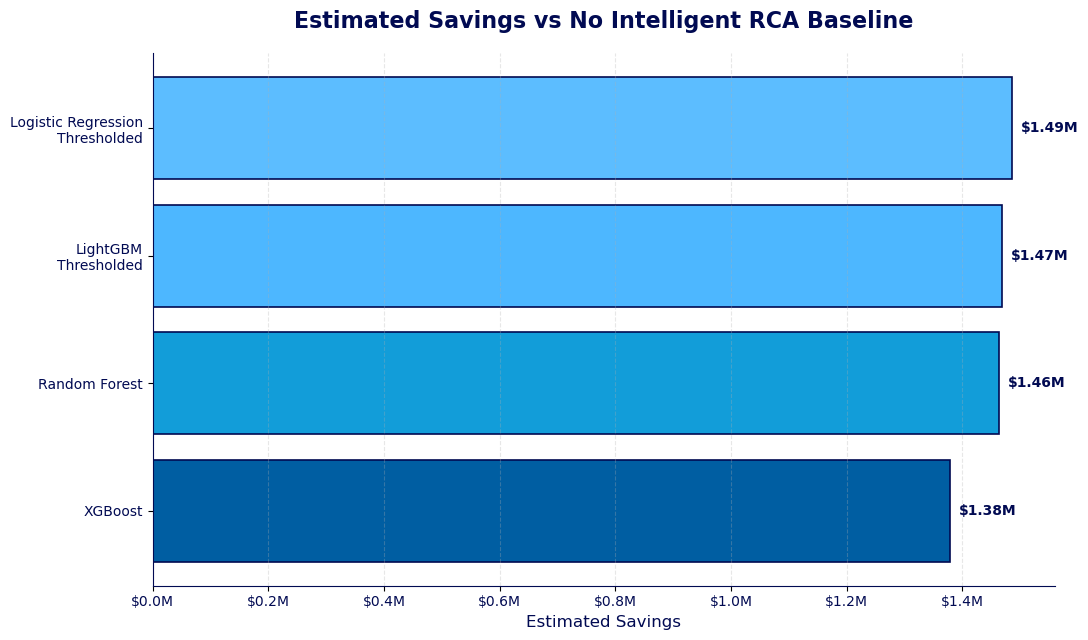

In [356]:
savings_df = cost_comparison_df[
    cost_comparison_df["Model"] != "No Intelligent RCA"
].copy()

savings_df = savings_df.sort_values(
    "Savings vs Baseline",
    ascending=True
)

plt.figure(figsize=(11, 6.5))

bars = plt.barh(
    savings_df["Model"],
    savings_df["Savings vs Baseline"],
    color=[DARK_BLUE, BLUE, LIGHT_BLUE, SKY],
    edgecolor=NAVY,
    linewidth=1.2
)

plt.title(
    "Estimated Savings vs No Intelligent RCA Baseline",
    fontsize=16,
    fontweight="bold",
    color=NAVY,
    pad=18
)

plt.xlabel(
    "Estimated Savings",
    fontsize=12,
    color=NAVY
)

plt.xticks(
    fontsize=10,
    color=NAVY
)

plt.yticks(
    fontsize=10,
    color=NAVY
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(dollars_millions)
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color(NAVY)
plt.gca().spines["bottom"].set_color(NAVY)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 15000,
        bar.get_y() + bar.get_height() / 2,
        f"${value/1_000_000:.2f}M",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

plt.tight_layout()
plt.show()